## Operator Benchmarks

Each row checks forward and backward correctness against `TorchOpsBackend`, then reports forward, backward-only, and full forward+backward p50 latency, p95 latency, peak CUDA memory delta, and speedup versus torch.


In [1]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "minitrain").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "tests"))

from minitrain.model.ops import get_ops_backend
from operator_nsight import nsight_kernel, register_nsight_kernel
from operator_bench_utils import (
    BenchCase,
    cuda_cleanup,
    benchmark_architecture_dir,
    bench_sweep,
    collect_triton_best_configs,
    display_triton_config_summary,
    plot_kernel_grid,
    save_benchmark_results,
    to_summary_dataframe,
)

torch.manual_seed(0)
assert torch.cuda.is_available(), "operator benchmarks require CUDA"

DEVICE = torch.device("cuda")
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
PROVIDERS = ("torch", "triton", "cuda")
WARMUP_MS = 10
REP_MS = 50
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
BENCHMARK_CACHE_DIR = PROJECT_ROOT / "tests" / "benchmark_results"
GPU_BENCHMARK_DIR = benchmark_architecture_dir(BENCHMARK_CACHE_DIR)
NSIGHT_REPORT_DIR = GPU_BENCHMARK_DIR / "nsight"
METRICS = (
    "fwd_p50_ms",
    "fwd_p95_ms",
    "fwd_peak_mem_mb",
    "fwd_speedup",
    "bwd_p50_ms",
    "bwd_p95_ms",
    "bwd_peak_mem_mb",
    "bwd_speedup",
    "full_p50_ms",
    "full_p95_ms",
    "full_peak_mem_mb",
    "full_speedup",
)

print(torch.__version__)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
NVIDIA GeForce RTX 3050 Laptop GPU


Each kernel section now provides `make_case(size)` and `forward(provider, tensors)`. The runner owns tensor cloning, forward/backward correctness, timing, memory measurement, and cleanup. Cleanup clears the torch-created tensor dictionary before releasing the CUDA cache.

Every completed dataset is cached in `tests/benchmark_results/<sm-arch>-<gpu-name>/<operator>/<UTC timestamp>.json`. Repeated runs are retained independently. The strict JSON cache retains raw correctness, latency, memory, speedup, Triton configuration, unsupported-branch, and error fields for later README generation.

Generate and cache a small Nsight Compute report with one line, for example `profile_and_cache_kernel("rmsnorm")` or `profile_and_cache_kernel("attention", mode="bwd")`. `size` uses the same logical size as the corresponding benchmark when explicitly provided. The default `LaunchStats` section reports launch geometry, registers, and shared memory; pass `set_name="basic"` for a broader, slower analysis. Autotuned kernels are tuned once before ncu starts, then the worker is pinned to the winning configuration.

In [2]:
def register_kernel(
    kernel,
    sizes,
    size_label,
    make_case,
    forward,
    *,
    nsight_size=None,
    nsight_autotune_kernels=None,
    nsight_provider="triton",
):
    sizes = tuple(sizes)
    register_nsight_kernel(
        kernel,
        make_case,
        forward,
        default_size=min(sizes) if nsight_size is None else nsight_size,
        provider=nsight_provider,
        autotune_kernels=nsight_autotune_kernels,
    )
    return sizes


def cache_benchmark_rows(benchmark, rows, **metadata):
    cache_path = save_benchmark_results(
        rows,
        benchmark=benchmark,
        cache_root=BENCHMARK_CACHE_DIR,
        metadata={
            "warmup_ms": WARMUP_MS,
            "rep_ms": REP_MS,
            **metadata,
        },
    )
    print(f"raw benchmark data: {cache_path}")
    return cache_path


@cuda_cleanup
def profile_and_cache_kernel(name, **kwargs):
    kwargs.setdefault("report_dir", NSIGHT_REPORT_DIR)
    result = nsight_kernel(name, **kwargs)
    cache_benchmark_rows(
        f"nsight_{name}_{result['mode']}_{result['size']}",
        [result],
        dataset_type="nsight",
    )
    return result


@cuda_cleanup
def run_kernel(
    kernel,
    sizes,
    size_label,
    make_case,
    forward,
    *,
    providers=None,
    autotune_kernels=None,
    nsight_size=None,
    nsight_autotune_kernels=None,
    nsight_provider="triton",
):
    sizes = register_kernel(
        kernel,
        sizes,
        size_label,
        make_case,
        forward,
        nsight_size=nsight_size,
        nsight_autotune_kernels=nsight_autotune_kernels,
        nsight_provider=nsight_provider,
    )
    providers = PROVIDERS if providers is None else tuple(providers)
    rows = bench_sweep(
        kernel=kernel,
        providers=providers,
        sizes=sizes,
        size_label=size_label,
        make_case=make_case,
        forward=forward,
        warmup_ms=WARMUP_MS,
        rep_ms=REP_MS,
        autotune_kernels=autotune_kernels,
    )
    cache_benchmark_rows(
        kernel,
        rows,
        providers=providers,
        size_label=size_label,
    )
    display(to_summary_dataframe(rows))
    plot_kernel_grid(rows, metrics=METRICS, save_path=FIG_DIR / f"{kernel}_summary.png")
    return rows


## RMSNorm

Sweep parameter: `rows`.

X-axis: activation tensor elements, `rows * hidden`.

raw benchmark data: c:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\rmsnorm\2026-07-17T06-04-59.560699_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,rmsnorm,torch,1048576,ok,True,True,0.000000,0.00000,0.319488,0.322202,10.003906,1.000000,0.899584,1.295770,20.004883,1.000000,1.116160,2.249677,34.013184,1.000000
1,rmsnorm,triton,1048576,ok,True,True,0.000000,0.03125,0.029696,0.030720,2.003906,10.758620,0.447488,0.529254,4.068848,2.010297,0.214016,0.216781,6.073242,5.215311
2,rmsnorm,torch,8388608,ok,True,True,0.000000,0.00000,2.245632,2.710323,80.031250,1.000000,5.206528,5.276672,108.004883,1.000000,7.941120,8.384512,220.040527,1.000000
3,rmsnorm,triton,8388608,ok,True,True,0.015625,0.03125,0.188416,0.189440,16.031250,11.918478,0.800256,0.828928,32.068848,6.506078,1.256960,1.277747,48.100586,6.317719
4,rmsnorm,torch,33554432,ok,True,True,0.000000,0.00000,8.768000,9.134233,320.125000,1.000000,20.410288,21.034804,400.004883,1.000000,30.993408,30.993408,848.134277,1.000000
5,rmsnorm,triton,33554432,ok,True,True,0.015625,0.25000,0.737280,0.738304,64.125000,11.892360,2.373120,2.460723,128.068848,8.600614,4.882432,4.947661,192.194336,6.347945
6,rmsnorm,torch,67108864,ok,True,True,0.000000,0.00000,17.467903,17.477581,640.250000,1.000000,40.212479,41.327309,800.004883,1.000000,61.776897,61.776897,1696.259277,1.000000
7,rmsnorm,triton,67108864,ok,True,True,0.015625,0.03125,1.470464,1.491558,128.250000,11.879178,4.612608,4.669489,256.068848,8.717949,9.746431,9.788519,384.319336,6.338412
8,rmsnorm,torch,100663296,ok,True,True,0.000000,0.00000,26.240000,26.240000,960.375000,1.000000,60.303873,60.595711,1200.004883,1.000000,91.906052,91.906052,2544.384277,1.000000
9,rmsnorm,triton,100663296,ok,True,True,0.015625,2.00000,2.203648,2.262835,192.375000,11.907527,6.834688,7.049984,384.068848,8.823208,14.528512,14.793933,576.444336,6.325909


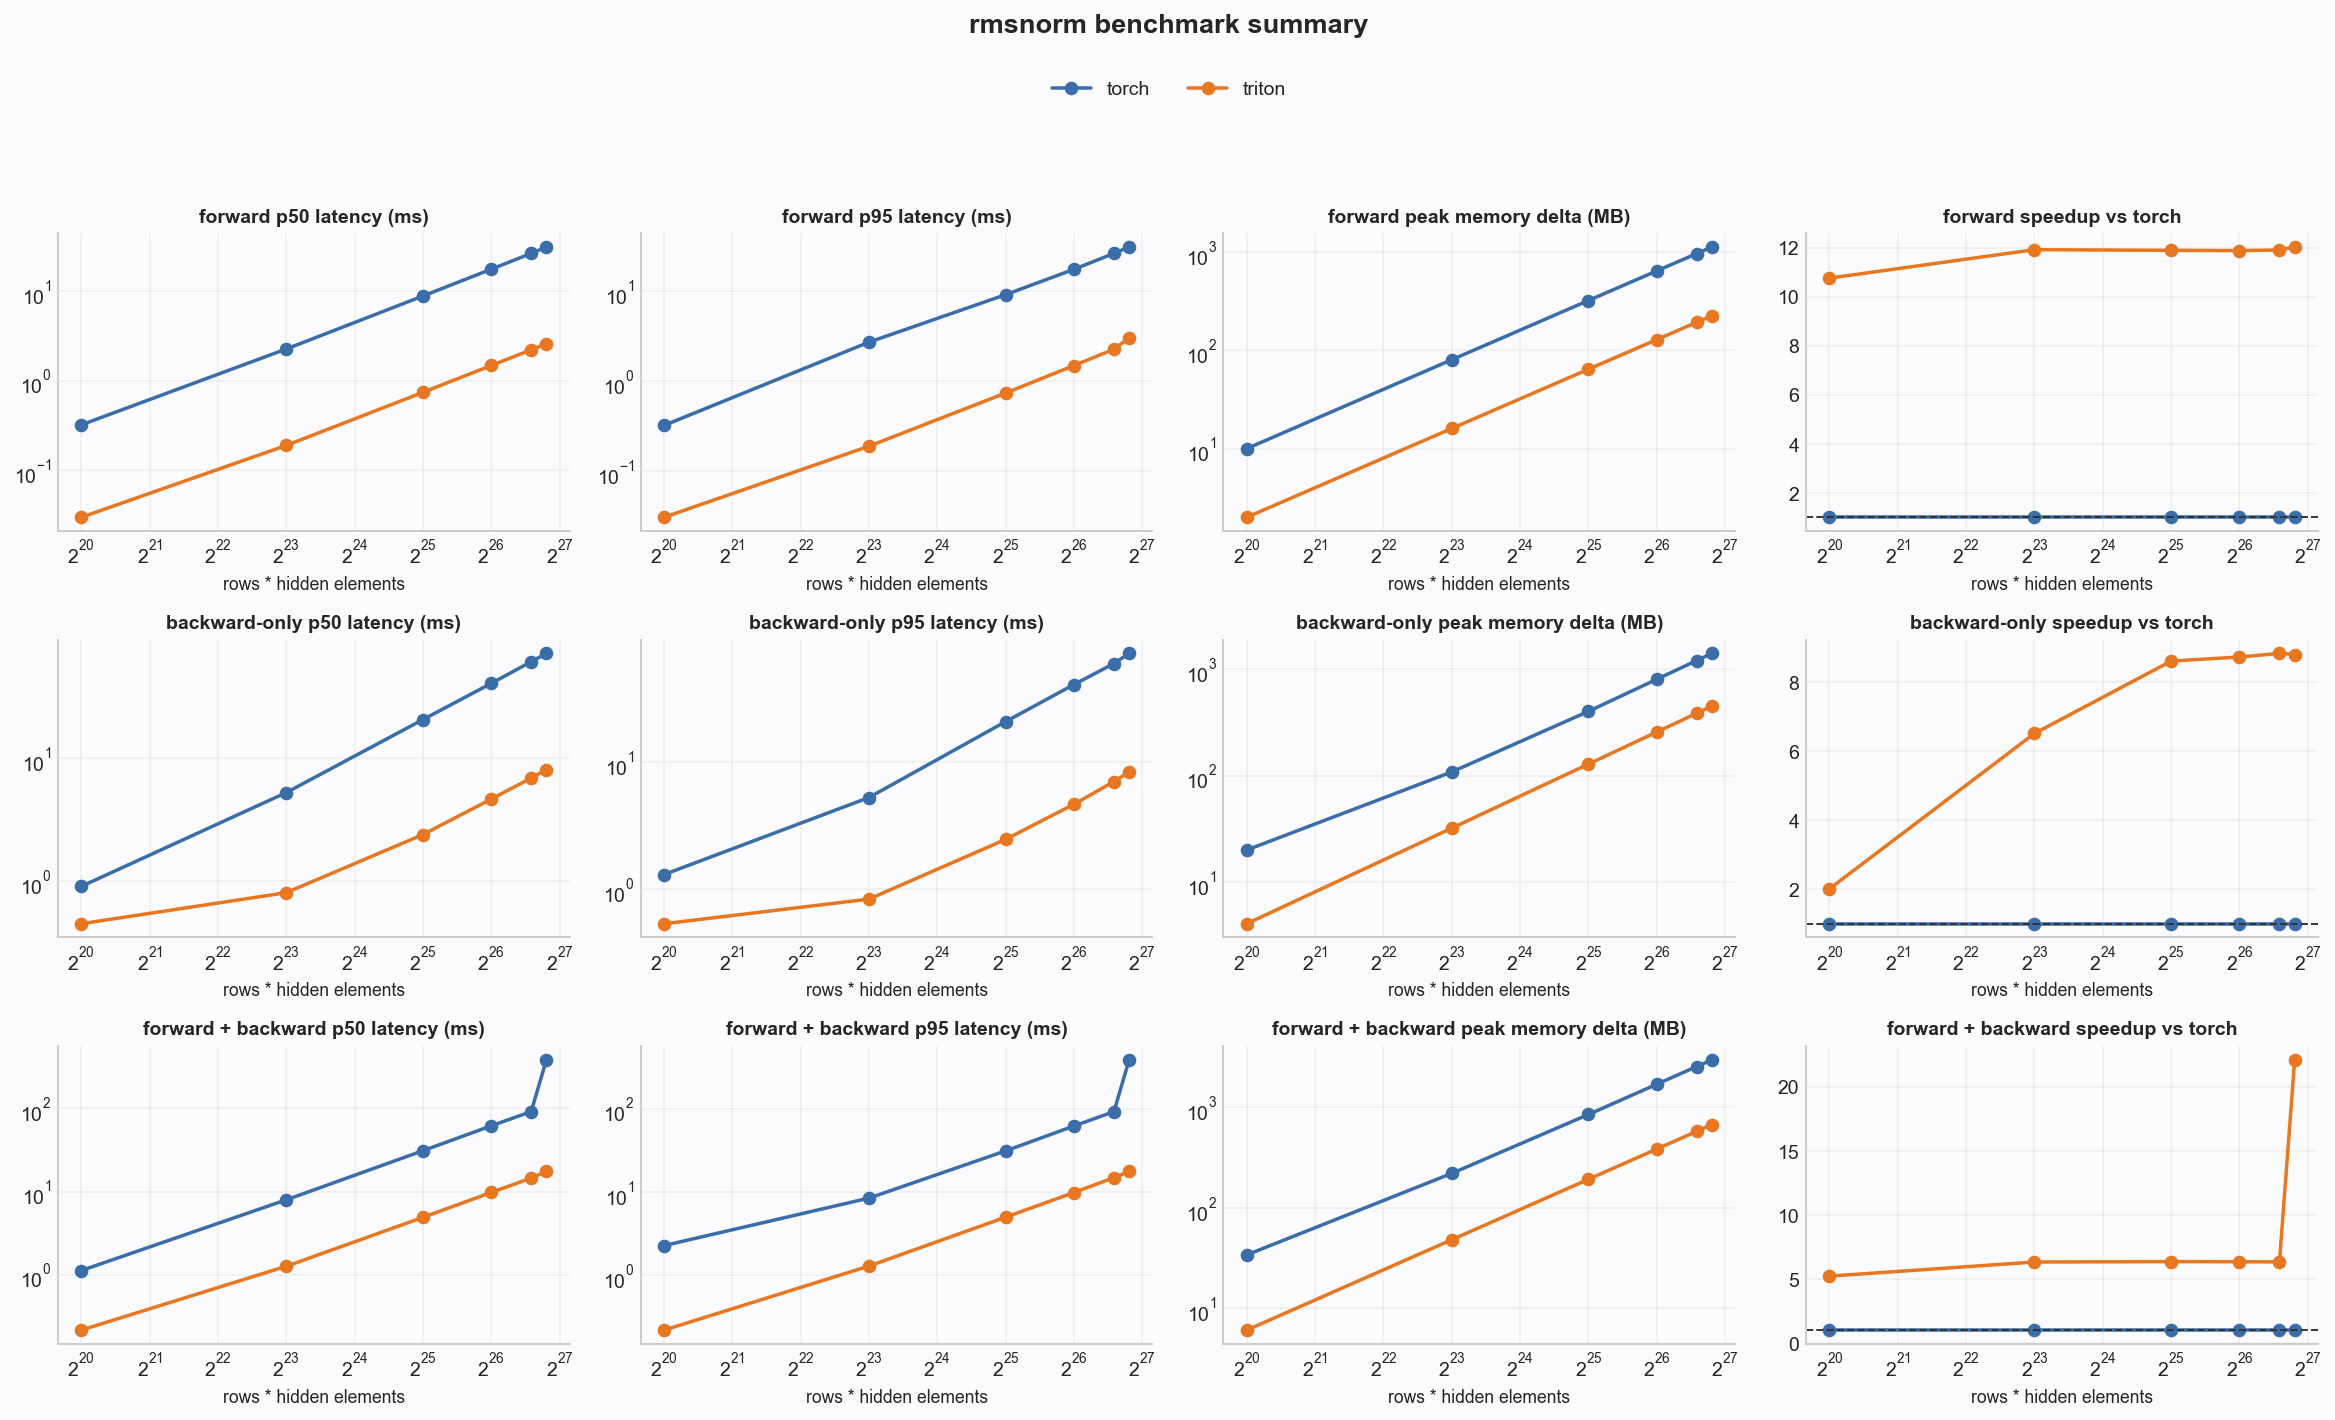

In [3]:
PROVIDERS = ("torch", "triton")
def make_rmsnorm_case(size):
    hidden = 1024
    rows = size // hidden
    return BenchCase(
        tensors={
            "x": torch.randn(rows, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.ones(hidden, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("x", "weight"),
    )


def rmsnorm_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rmsnorm(tensors["x"], tensors["weight"], 1e-5)


rmsnorm_sizes = [1024 * rows for rows in (1024, 8192, 32768, 65536, 98304, 114688)]
rmsnorm_rows = run_kernel(
    "rmsnorm",
    rmsnorm_sizes,
    "rows * hidden elements",
    make_rmsnorm_case,
    rmsnorm_forward,
)

## RoPE

Sweep parameter: `seq`.

X-axis: Q+K tensor elements, `2 * batch * heads * seq * head_dim`.

raw benchmark data: c:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\rope\2026-07-17T06-17-21.059664_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,rope,torch,4194304,ok,True,True,0.0,0.0,0.691200,0.696218,16.0,1.000000,1.081856,1.597696,20.000488,1.000000,1.923072,2.450278,28.000977,1.000000
1,rope,triton,4194304,ok,True,True,0.0,0.0,0.100352,0.101376,8.0,6.887756,0.499616,0.611533,16.000488,2.165375,0.706048,0.707584,24.000977,2.723713
2,rope,torch,33554432,ok,True,True,0.0,0.0,5.139456,5.490688,128.0,1.000000,7.687536,8.180173,160.000488,1.000000,14.062592,14.574080,224.000977,1.000000
3,rope,triton,33554432,ok,True,True,0.0,0.0,0.759808,1.043661,64.0,6.764151,2.371072,2.419866,128.000488,3.242220,4.882432,4.954522,192.000977,2.880243
4,rope,torch,134217728,ok,True,True,0.0,0.0,20.855297,20.998606,512.0,1.000000,28.145056,28.784405,640.000488,1.000000,56.558594,56.558594,896.000977,1.000000
5,rope,triton,134217728,ok,True,True,0.0,0.0,3.025920,3.271680,256.0,6.892217,8.928768,9.247693,512.000488,3.152177,19.442688,19.461119,768.000977,2.908990
6,rope,torch,201326592,ok,True,True,0.0,0.0,31.158272,31.158272,768.0,1.000000,42.227200,42.503885,960.000488,1.000000,84.645889,84.645889,1344.000977,1.000000
7,rope,triton,201326592,ok,True,True,0.0,0.0,4.537344,4.832973,384.0,6.867073,13.357984,13.806848,768.000488,3.161196,29.176832,29.176832,1152.000977,2.901134
8,rope,torch,268435456,ok,True,True,0.0,0.0,42.995712,42.995712,1024.0,1.000000,56.445457,57.899675,1280.000488,1.000000,113.012733,113.012733,1792.000977,1.000000
9,rope,triton,268435456,ok,True,True,0.0,0.0,6.046720,6.343552,512.0,7.110584,17.662432,18.333010,1024.000488,3.195792,38.710274,38.710274,1536.000977,2.919451


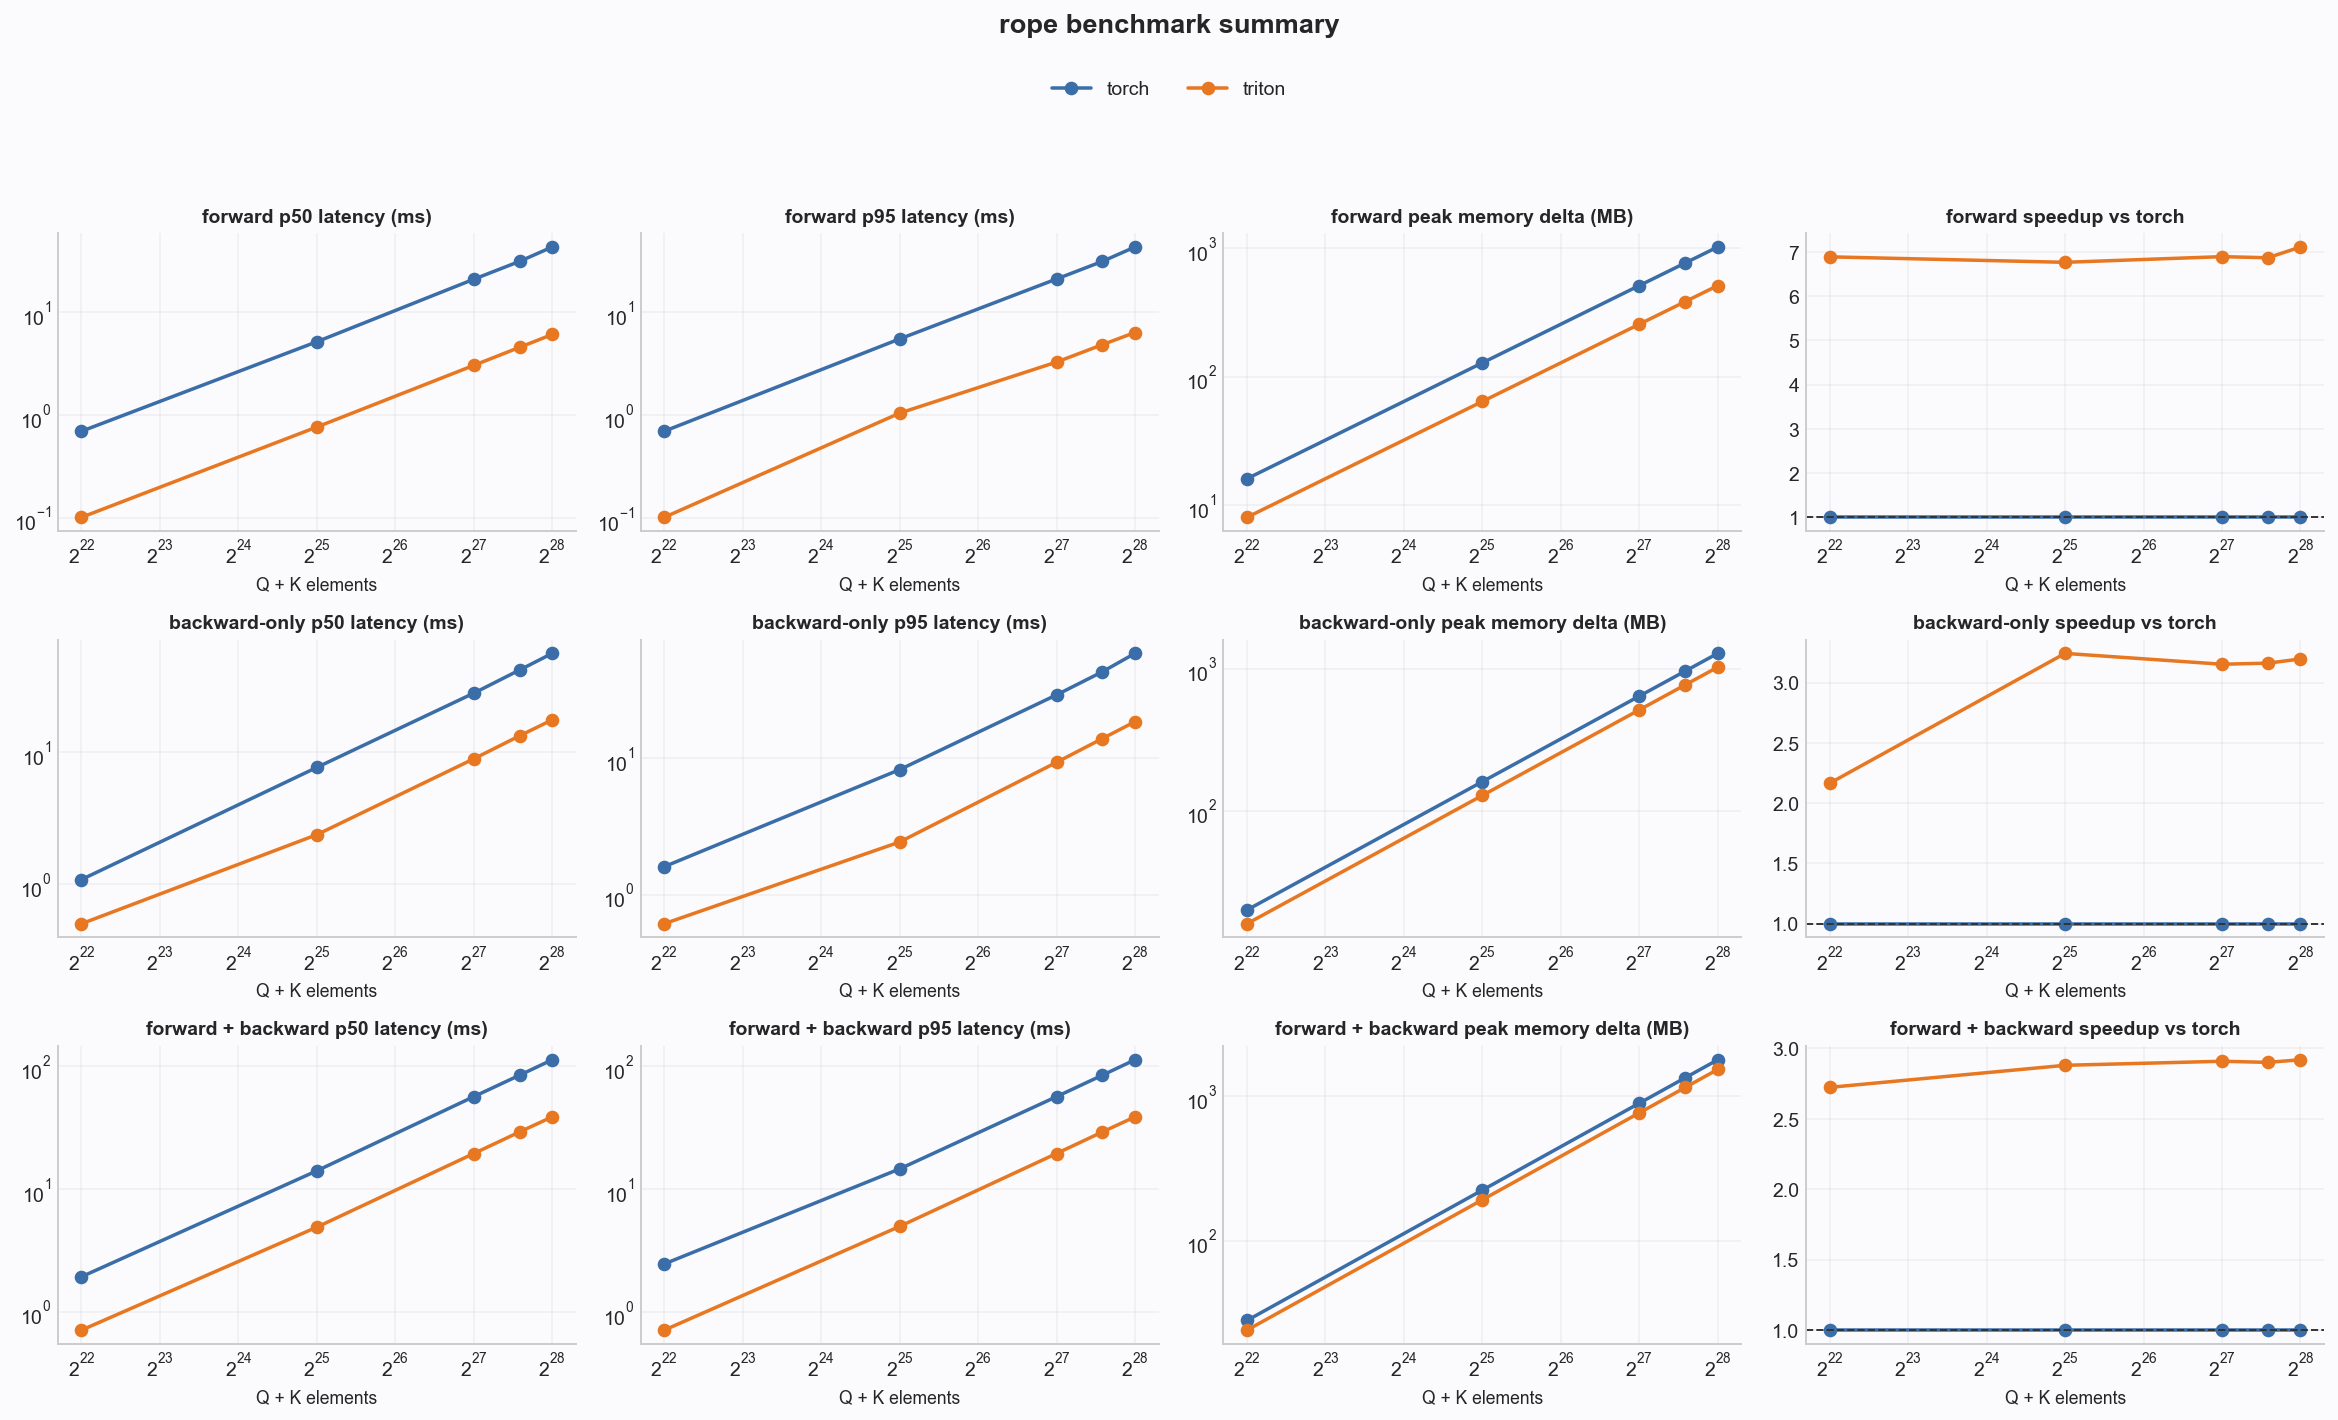

In [3]:
PROVIDERS = ("torch", "triton")
def rope_cache(seq, dim):
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=DEVICE).float() / dim))
    freqs = torch.outer(torch.arange(seq, device=DEVICE).float(), inv_freq)
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos().to(dtype=DTYPE), emb.sin().to(dtype=DTYPE)


def make_rope_case(size):
    batch, heads, head_dim = 1, 8, 64
    seq = size // (2 * batch * heads * head_dim)
    cos, sin = rope_cache(seq, head_dim)
    return BenchCase(
        tensors={
            "q": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "cos": cos,
            "sin": sin,
        },
        grad_names=("q", "k"),
    )


def rope_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rope(tensors["q"], tensors["k"], tensors["cos"], tensors["sin"])


rope_sizes = [2 * 1 * 8 * seq * 64 for seq in (4096, 32768, 131072, 196608, 262144)]
rope_rows = run_kernel("rope", rope_sizes, "Q + K elements", make_rope_case, rope_forward)


## SwiGLU

Sweep parameter: `rows`.

X-axis: input tensor elements, `2 * rows * intermediate` for gate and up.

raw benchmark data: c:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\swiglu\2026-07-17T06-09-44.776952_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,swiglu,torch,2097152,ok,True,True,0.0,0.0000,0.066560,0.069274,4.0,1.000000,0.239040,0.383334,6.000488,1.000000,0.287744,0.291379,10.000977,1.000000
1,swiglu,triton,2097152,ok,True,True,0.0,0.0625,0.040960,0.041984,2.0,1.625000,0.345008,0.576819,6.000488,0.692854,0.207872,0.209920,8.000977,1.384236
2,swiglu,torch,16777216,ok,True,True,0.0,0.0000,0.464896,0.465920,32.0,1.000000,1.148896,1.285581,48.000488,1.000000,1.990656,2.656256,80.000977,1.000000
3,swiglu,triton,16777216,ok,True,True,0.0,0.0625,0.277504,0.278528,16.0,1.675277,0.772096,0.844411,48.000488,1.488022,1.434624,1.447117,64.000977,1.387580
4,swiglu,torch,67108864,ok,True,True,0.0,0.0000,1.830912,1.843610,128.0,1.000000,4.044800,4.396954,192.000488,1.000000,7.836672,8.121754,320.000977,1.000000
5,swiglu,triton,67108864,ok,True,True,0.0,0.0625,1.093632,1.145907,64.0,1.674157,2.726400,3.086131,192.000488,1.483568,5.411840,5.483110,256.000977,1.448061
6,swiglu,torch,134217728,ok,True,True,0.0,0.0000,4.023296,4.326208,256.0,1.000000,7.998464,8.194933,384.000488,1.000000,15.794176,15.824589,640.000977,1.000000
7,swiglu,triton,134217728,ok,True,True,0.0,0.0625,2.183168,2.254643,128.0,1.842871,5.008832,5.325722,384.000488,1.596872,10.828800,11.080038,512.000977,1.458534
8,swiglu,torch,268435456,ok,True,True,0.0,0.0000,7.292928,7.632486,512.0,1.000000,15.675296,15.975834,768.000488,1.000000,30.379007,30.379007,1280.000977,1.000000
9,swiglu,triton,268435456,ok,True,True,0.0,0.0625,4.361216,4.633191,256.0,1.672224,10.185680,10.558515,768.000488,1.538954,21.799423,21.987892,1024.000977,1.393569


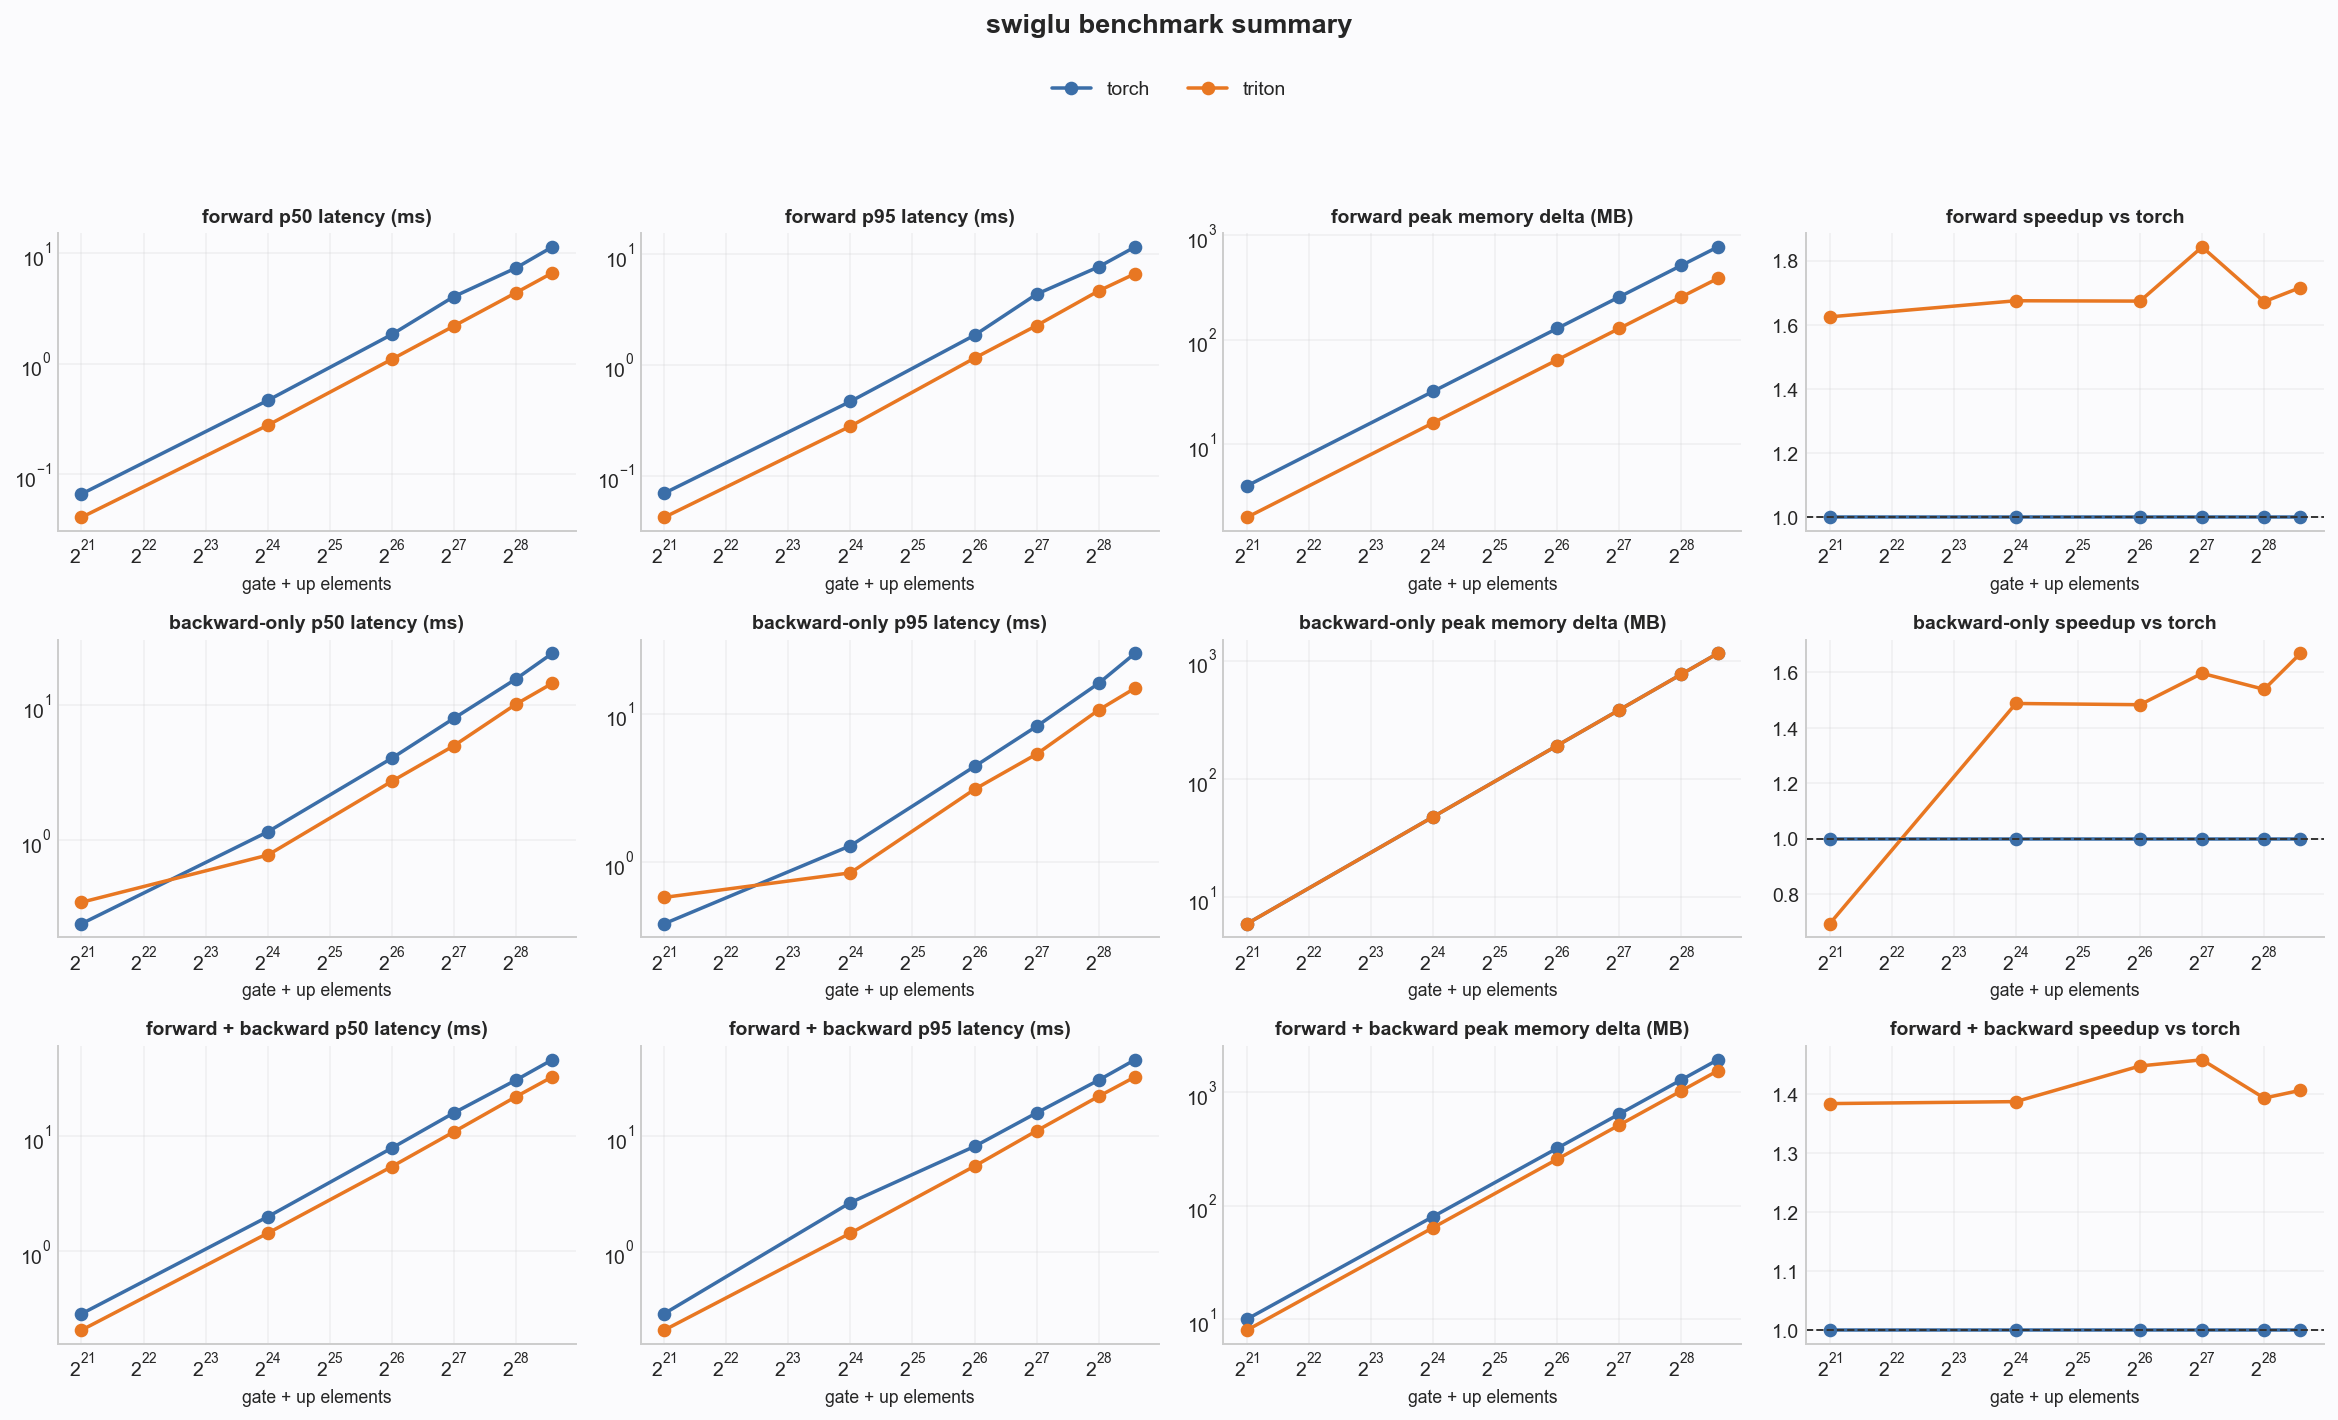

In [3]:
PROVIDERS = ("torch", "triton")
def make_swiglu_case(size):
    intermediate = 1024
    rows = size // (2 * intermediate)
    return BenchCase(
        tensors={
            "gate": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
            "up": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("gate", "up"),
    )


def swiglu_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.swiglu(tensors["gate"], tensors["up"])


swiglu_sizes = [2 * rows * 1024 for rows in (1024, 8192, 32768, 65536, 131072, 196608)]
swiglu_rows = run_kernel(
    "swiglu",
    swiglu_sizes,
    "gate + up elements",
    make_swiglu_case,
    swiglu_forward,
)


## CrossEntropy

Sweep parameter: `vocab` at a fixed 256 tokens.

X-axis: logits tensor elements, `tokens * vocab`.

raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\cross-entropy\2026-07-15T17-57-26.905157_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,cross_entropy,torch,8388608,ok,True,True,0.0,0.0,0.633248,0.684544,48.000977,1.000000,0.941056,0.966707,32.000488,1.000000,1.471952,1.857818,80.001953,1.000000
1,cross_entropy,triton,8388608,ok,True,True,0.0,0.0,0.648640,0.702106,48.000977,0.976270,0.986112,1.208669,32.000488,0.954309,1.474560,1.592883,80.001953,0.998231
2,cross_entropy,torch,33554432,ok,True,True,0.0,0.0,2.285056,2.727885,192.000977,1.000000,3.455488,3.845171,128.000488,1.000000,5.674928,6.119987,320.001953,1.000000
3,cross_entropy,triton,33554432,ok,True,True,0.0,0.0,2.173936,2.226944,192.000977,1.051115,3.551232,3.852032,128.000488,0.973039,5.577664,6.041027,320.001953,1.017438
4,cross_entropy,torch,67108864,ok,True,True,0.0,0.0,5.400064,5.707307,384.000977,1.000000,6.840832,7.199285,256.000488,1.000000,12.317696,12.816998,640.001953,1.000000
5,cross_entropy,triton,67108864,ok,True,True,0.0,0.0,5.416432,5.744179,384.000977,0.996978,6.820288,7.116595,256.000488,1.003012,12.376112,12.697805,640.001953,0.995280
6,cross_entropy,torch,134217728,ok,True,True,0.0,0.0,10.875904,11.237734,768.000977,1.000000,13.739008,14.201856,512.000488,1.000000,24.552336,24.989697,1280.001953,1.000000
7,cross_entropy,triton,134217728,ok,True,True,0.0,0.0,10.998272,11.149514,768.000977,0.988874,13.758352,14.230220,512.000488,0.998594,24.366591,24.950733,1280.001953,1.007623
8,cross_entropy,torch,201326592,ok,True,True,0.0,0.0,16.377855,16.734895,1152.000977,1.000000,20.344721,20.752486,768.000488,1.000000,36.621824,37.201667,1920.001953,1.000000
9,cross_entropy,triton,201326592,ok,True,True,0.0,0.0,16.389632,16.766925,1152.000977,0.999281,20.412304,20.788070,768.000488,0.996689,36.585985,37.157414,1920.001953,1.000980


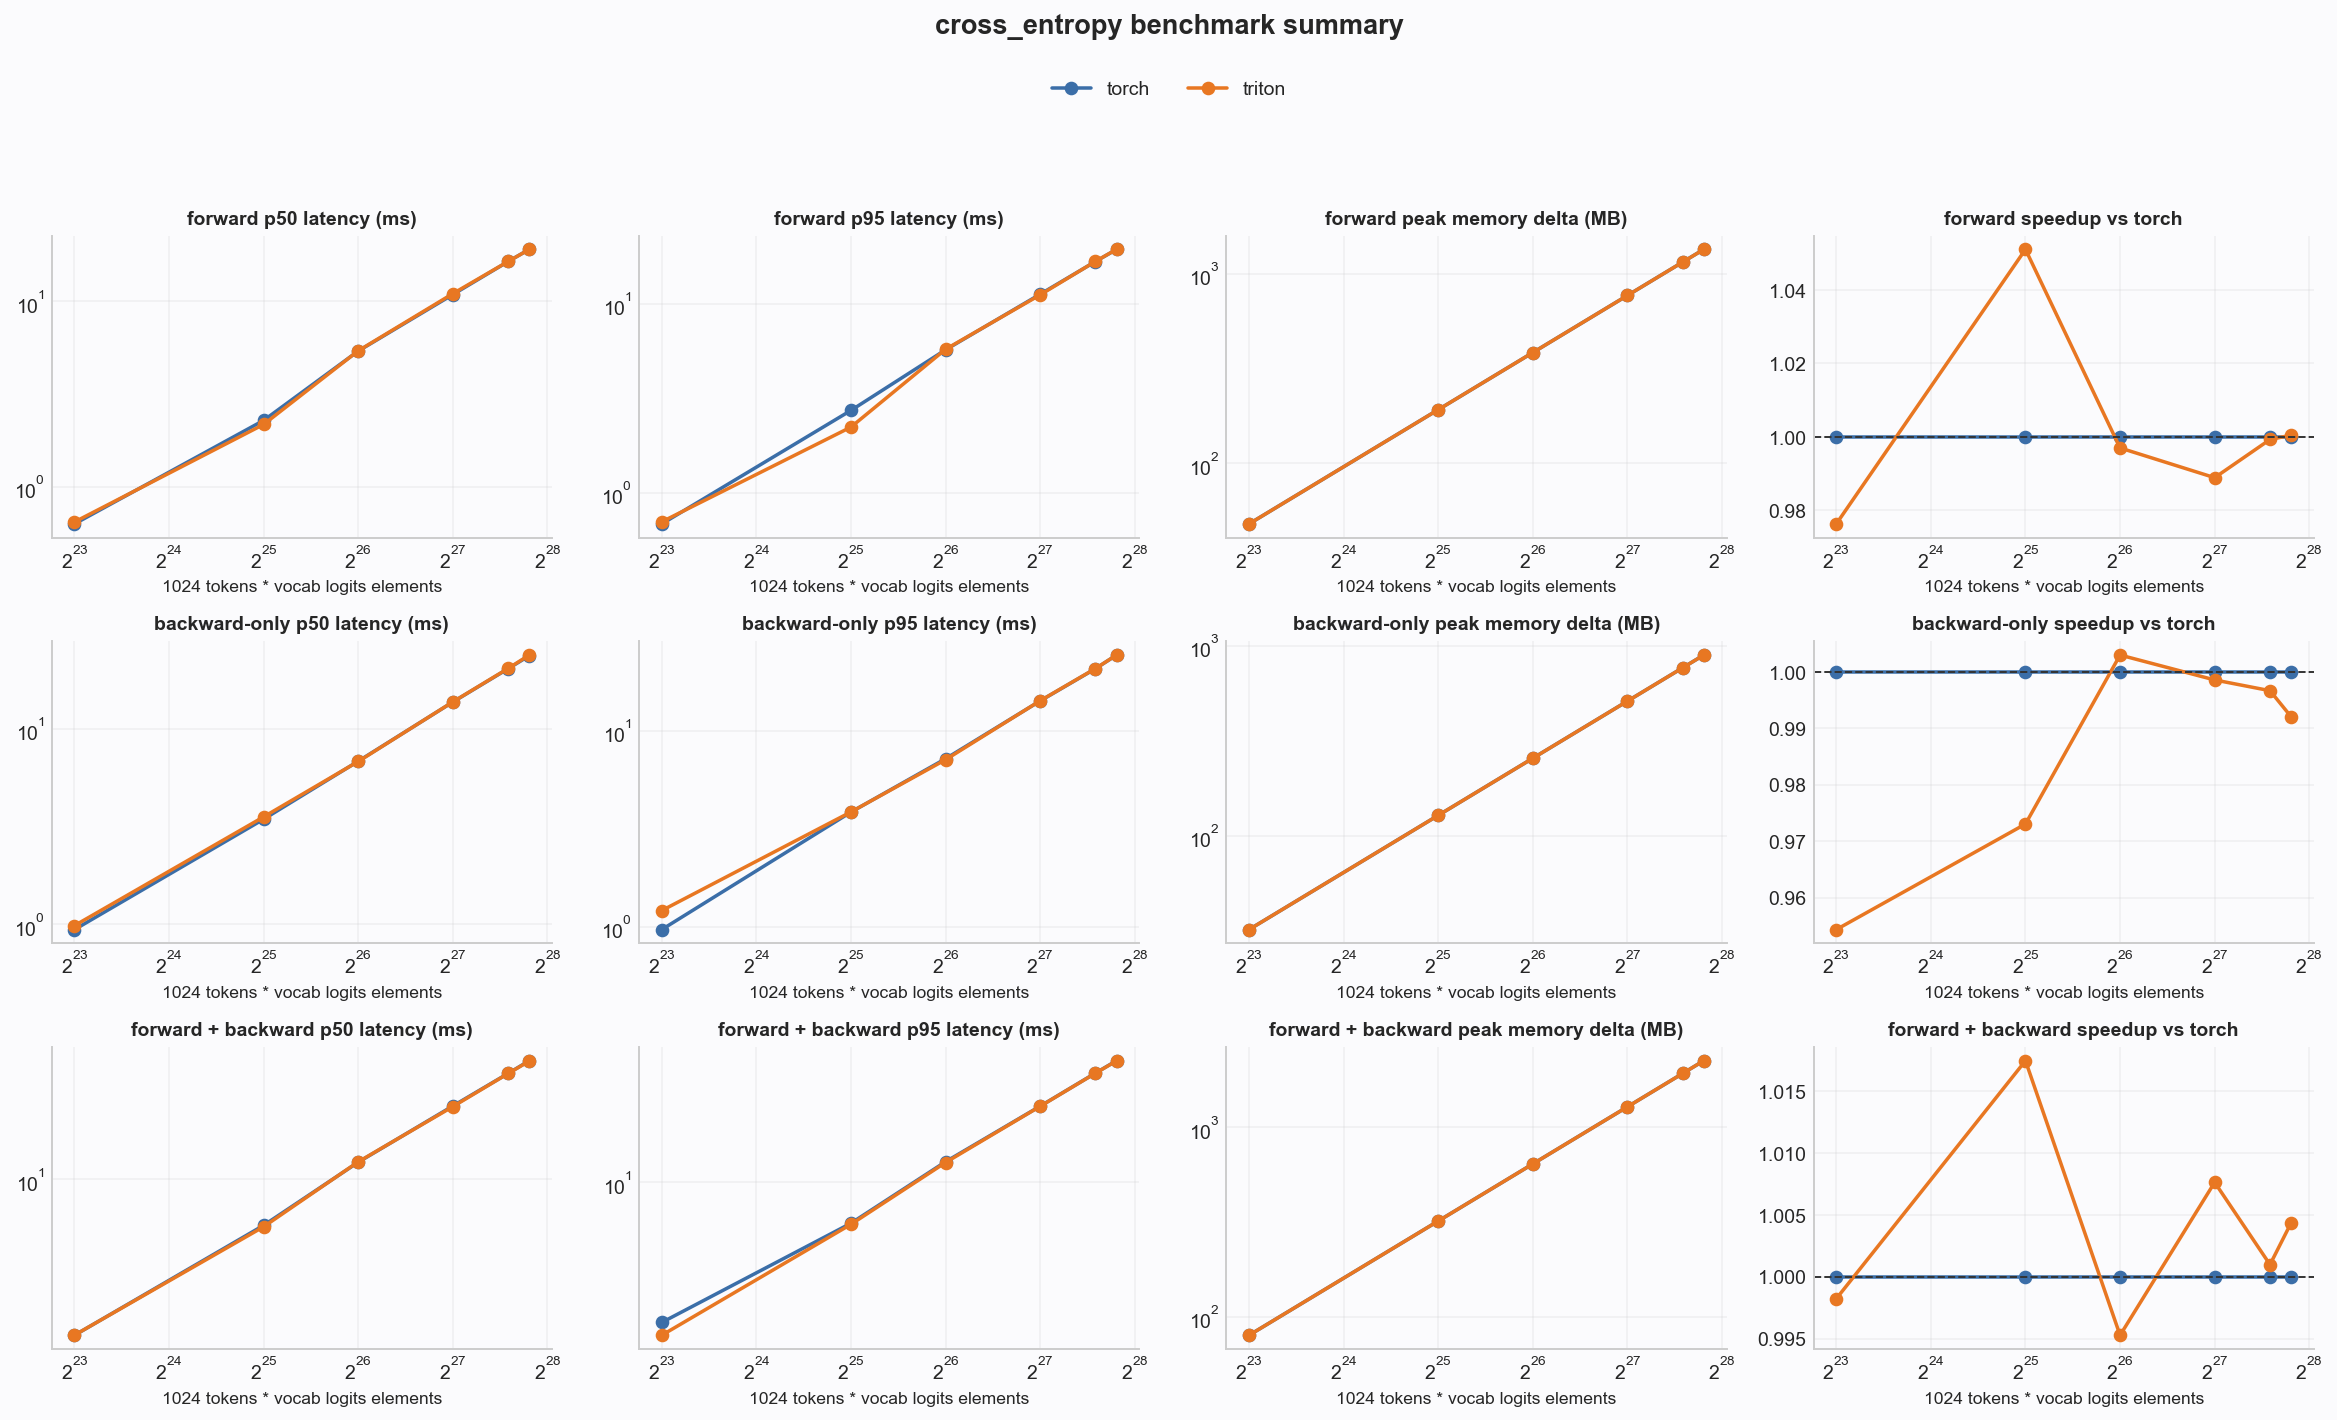

In [6]:
PROVIDERS = ("torch", "triton")
def make_cross_entropy_case(size):
    tokens = 1024
    vocab = size // tokens
    return BenchCase(
        tensors={
            "logits": torch.randn(tokens, vocab, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("logits",),
    )


def cross_entropy_forward(provider, tensors):
    backend = get_ops_backend(provider)
    # Match the trainer's mixed-precision contract: CE returns an fp32 scalar.
    with torch.autocast("cuda", dtype=DTYPE):
        return backend.cross_entropy(tensors["logits"], tensors["targets"])


cross_entropy_sizes = [1024 * vocab for vocab in (8192, 32768, 65536, 131072, 196608, 229376)]
cross_entropy_rows = run_kernel(
    "cross_entropy",
    cross_entropy_sizes,
    "1024 tokens * vocab logits elements",
    make_cross_entropy_case,
    cross_entropy_forward,
)

## FusedLinearCrossEntropy

Sweep parameter: `vocab`.

X-axis: logical logits elements, `tokens * vocab`. This is the tensor a fused implementation tries not to materialize.

raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\fused-linear-cross-entropy\2026-07-15T17-58-24.448546_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup
0,fused_linear_cross_entropy,torch,2097152,ok,True,True,0.0,0.0,0.399360,0.405555,16.000977,1.000000,0.716752,0.809573,8.000488,1.000000,1.024000,1.411320,20.001953,1.000000
1,fused_linear_cross_entropy,triton,2097152,ok,True,True,0.0,0.0,0.402944,0.413742,16.000977,0.991105,0.745472,0.803277,8.000488,0.961474,1.049088,1.116314,20.001953,0.976086
2,fused_linear_cross_entropy,torch,8388608,ok,True,True,0.0,0.0,1.430528,1.476219,64.000977,1.000000,2.453952,2.533222,32.000488,1.000000,3.831808,4.238245,80.001953,1.000000
3,fused_linear_cross_entropy,triton,8388608,ok,True,True,0.0,0.0,1.296384,1.315891,64.000977,1.103476,2.473392,2.861722,32.000488,0.992140,3.418112,3.774976,80.001953,1.121031
4,fused_linear_cross_entropy,torch,33554432,ok,True,True,0.0,0.0,5.225472,5.618608,256.000977,1.000000,8.542144,8.835332,128.000488,1.000000,13.757440,14.129962,320.001953,1.000000
5,fused_linear_cross_entropy,triton,33554432,ok,True,True,0.0,0.0,5.217280,5.553049,256.000977,1.001570,8.496128,9.108706,128.000488,1.005416,13.773312,16.045260,320.001953,0.998848
6,fused_linear_cross_entropy,torch,67108864,ok,True,True,0.0,0.0,10.419712,10.733978,512.000977,1.000000,17.216960,17.493299,256.000488,1.000000,27.613696,28.067389,640.001953,1.000000
7,fused_linear_cross_entropy,triton,67108864,ok,True,True,0.0,0.0,10.509328,10.678272,512.000977,0.991473,17.298320,17.434286,256.000488,0.995297,27.649535,27.979162,640.001953,0.998704
8,fused_linear_cross_entropy,torch,134217728,ok,True,True,0.0,0.0,20.757487,21.261620,1024.000977,1.000000,34.305489,34.781954,512.000488,1.000000,54.878208,55.537101,1280.001953,1.000000
9,fused_linear_cross_entropy,triton,134217728,ok,True,True,0.0,0.0,20.820992,21.143809,1024.000977,0.996950,34.393600,34.681499,512.000488,0.997438,54.990335,55.264615,1280.001953,0.997961


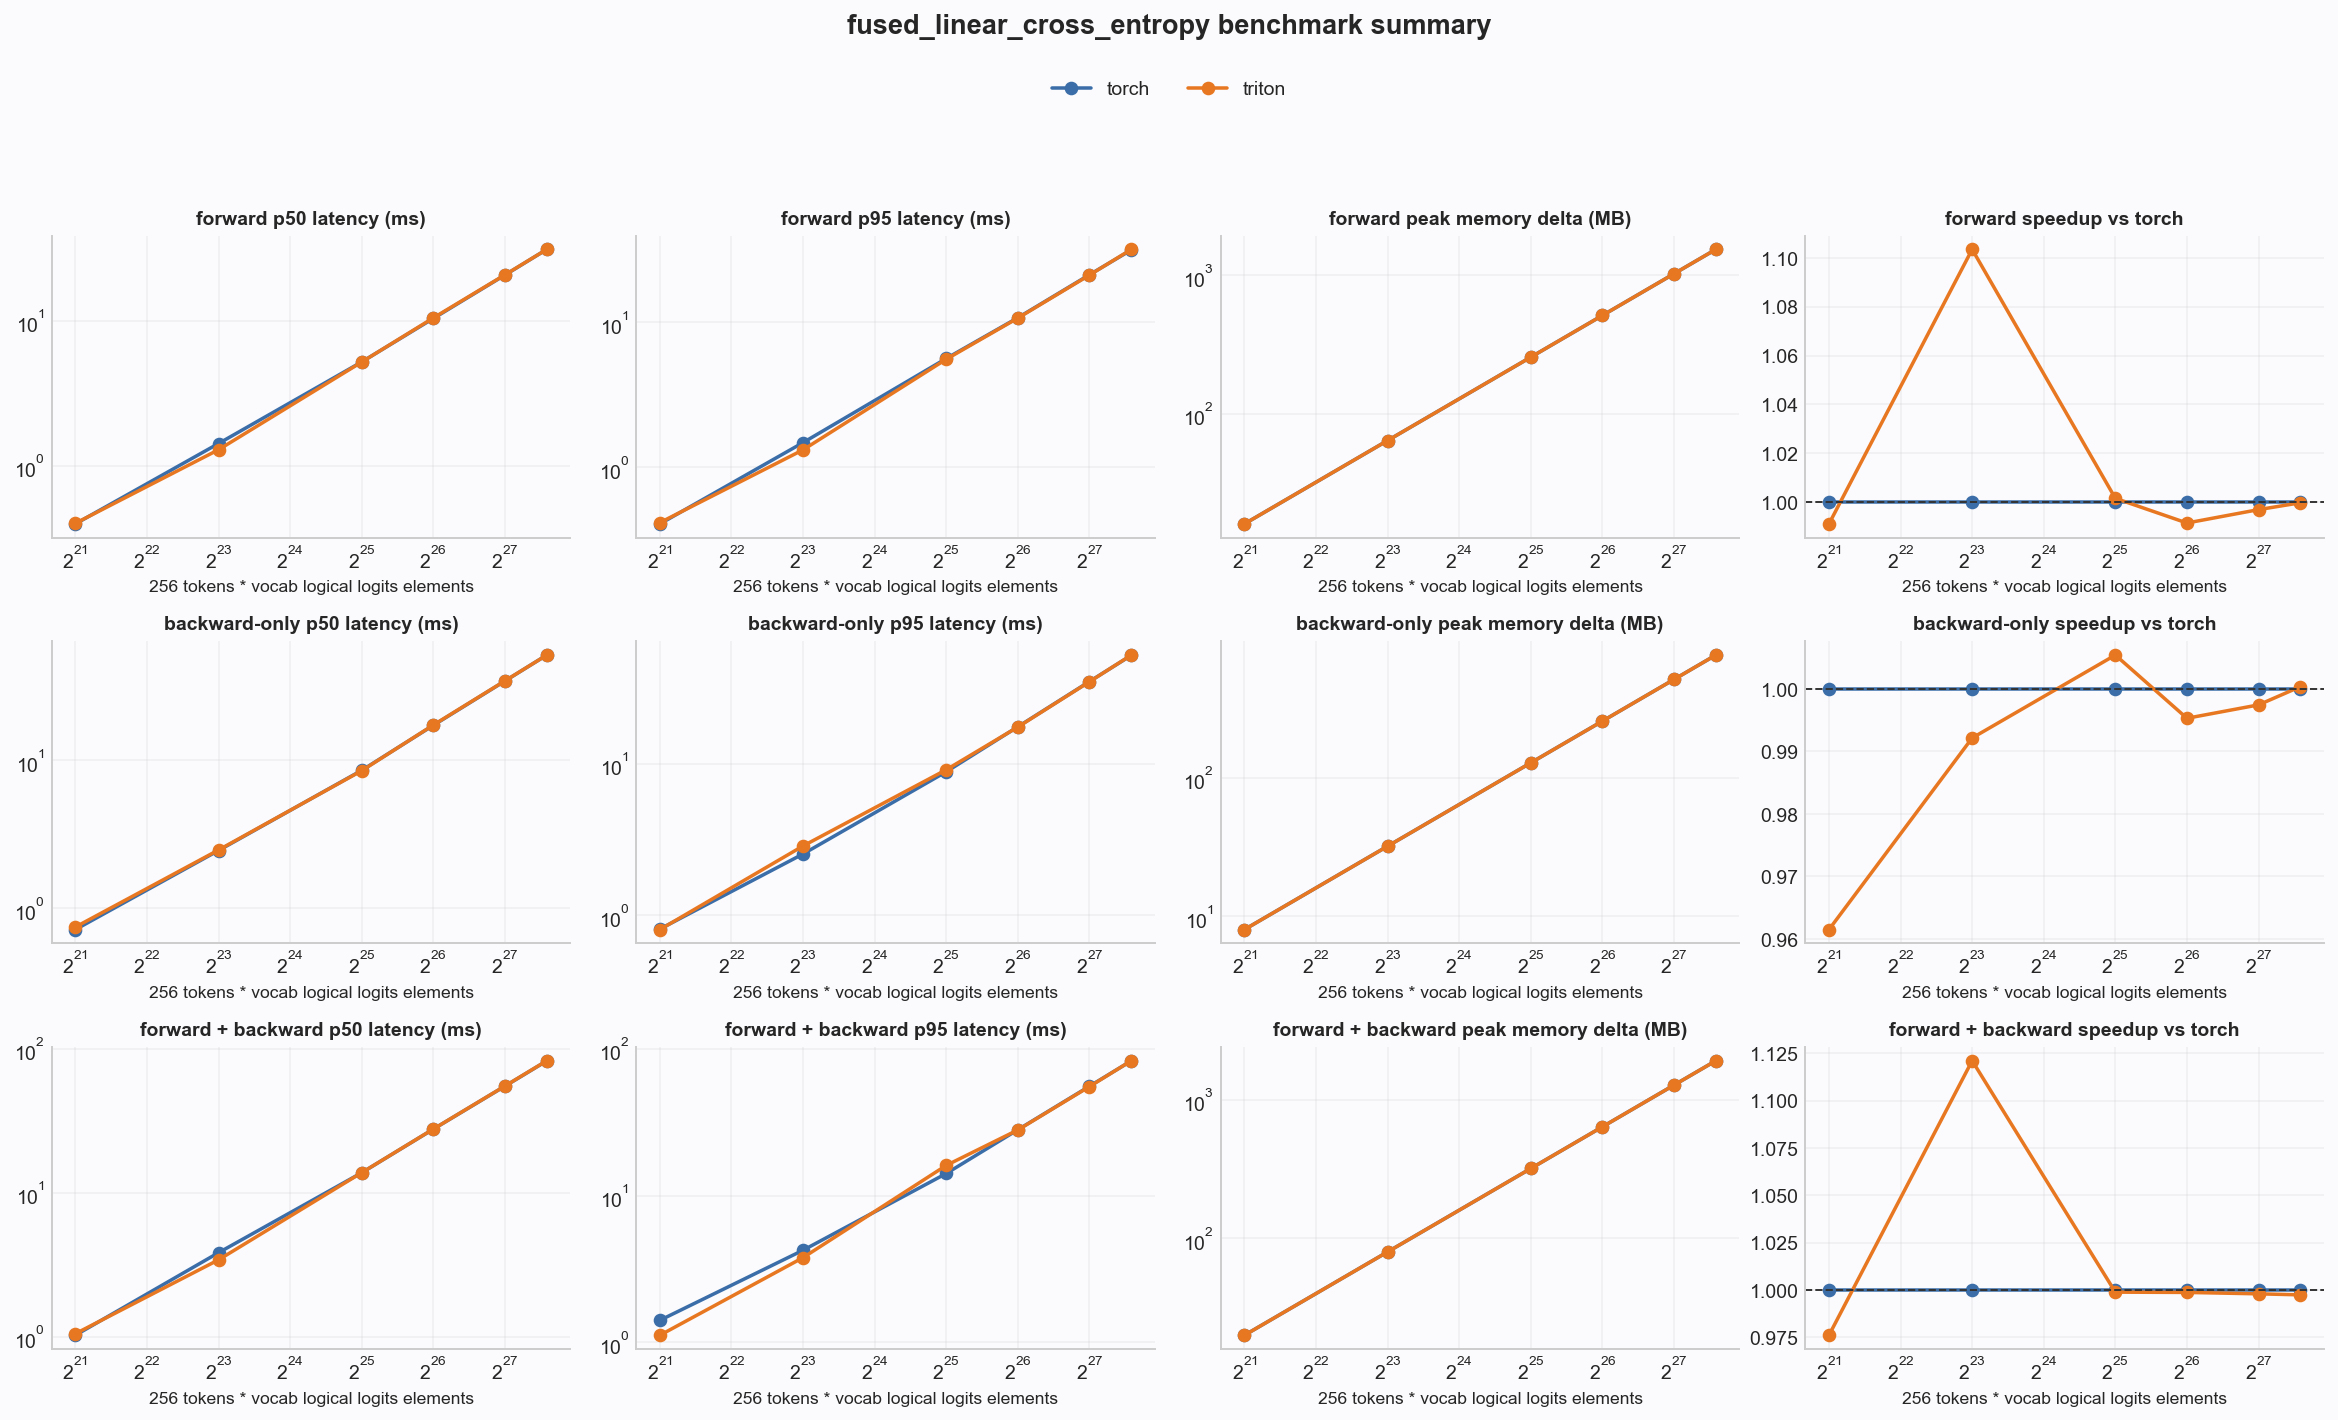

In [7]:
def make_fused_linear_ce_case(size):
    tokens, hidden = 256, 512
    vocab = size // tokens
    return BenchCase(
        tensors={
            "x": torch.randn(tokens, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.randn(vocab, hidden, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("x", "weight"),
    )


def fused_linear_ce_forward(provider, tensors):
    backend = get_ops_backend(provider)
    # Exercise the same autocast path used by MiniTransformer training.
    with torch.autocast("cuda", dtype=DTYPE):
        return backend.fused_linear_cross_entropy(
            tensors["x"], tensors["weight"], tensors["targets"]
        )


fused_linear_ce_sizes = [256 * vocab for vocab in (8192, 32768, 131072, 262144, 524288, 786432)]
fused_linear_ce_rows = run_kernel(
    "fused_linear_cross_entropy",
    fused_linear_ce_sizes,
    "256 tokens * vocab logical logits elements",
    make_fused_linear_ce_case,
    fused_linear_ce_forward,
)


## FlashAttention


### Shared configuration and helpers

One QKV case factory and one provider-checked forward factory are reused by the no-dropout sweep, dropout sweep, and specialization matrix.


In [8]:
from functools import partial
from itertools import product
import math

import pandas as pd
import torch.nn.functional as F
from torch.profiler import ProfilerActivity

from minitrain.kernels.cuda_ext.build import get_build_config as get_cuda_build_config
from minitrain.kernels.cuda_ext.flash_attention import (
    flash_attention_dropout_mask_for_testing as cuda_flash_attention_dropout_mask,
    is_flash_attention_supported as is_cuda_flash_attention_supported,
)
from minitrain.kernels.triton.flash_attention import (
    flash_attention_autotune_kernels,
    flash_attention_backward,
    flash_attention_dropout_mask,
    flash_attention_forward,
    is_flash_attention_supported as is_triton_flash_attention_supported,
)
from operator_bench_utils import benchmark_step, release_cache

ATTENTION_INPUT_NAMES = ("q", "k", "v")
ATTENTION_PROVIDERS = ("torch", "triton", "cuda")
ATTENTION_SIZE_LABEL = "Q + K + V elements"
ATTENTION_BENCHMARK_MODES = ("fwd", "bwd")

ATTENTION_BATCH_SIZE = 1
ATTENTION_NUM_HEADS = 4
ATTENTION_HEAD_DIM = 64
ATTENTION_SEQUENCE_LENGTHS = (256, 512, 1024, 2048)
ATTENTION_MEMORY_BOUNDARY_BATCH_SIZE = 1536
ATTENTION_MEMORY_BOUNDARY_SEQUENCE_LENGTH = 256
ATTENTION_CAUSAL = True
ATTENTION_DROPOUT_RATE = 0.1

SDPA_ATEN_BACKENDS = (
    ("aten::_scaled_dot_product_flash_attention", "flash_attention"),
    ("aten::_scaled_dot_product_efficient_attention", "memory_efficient_attention"),
    ("aten::_scaled_dot_product_cudnn_attention", "cudnn_attention"),
    ("aten::_scaled_dot_product_attention_math", "math"),
)


def attention_element_count(
    sequence_length,
    *,
    batch_size=ATTENTION_BATCH_SIZE,
    num_heads=ATTENTION_NUM_HEADS,
    head_dim=ATTENTION_HEAD_DIM,
):
    return 3 * batch_size * num_heads * sequence_length * head_dim


ATTENTION_MEMORY_BOUNDARY_SIZE = attention_element_count(
    ATTENTION_MEMORY_BOUNDARY_SEQUENCE_LENGTH,
    batch_size=ATTENTION_MEMORY_BOUNDARY_BATCH_SIZE,
)


def make_attention_case(
    size,
    *,
    batch_size=ATTENTION_BATCH_SIZE,
    num_heads=ATTENTION_NUM_HEADS,
    head_dim=ATTENTION_HEAD_DIM,
    dtype=DTYPE,
):
    elements_per_token = 3 * batch_size * num_heads * head_dim
    if (
        size == ATTENTION_MEMORY_BOUNDARY_SIZE
        and batch_size == ATTENTION_BATCH_SIZE
        and num_heads == ATTENTION_NUM_HEADS
        and head_dim == ATTENTION_HEAD_DIM
    ):
        batch_size = ATTENTION_MEMORY_BOUNDARY_BATCH_SIZE
        sequence_length = ATTENTION_MEMORY_BOUNDARY_SEQUENCE_LENGTH
        remainder = 0
    else:
        sequence_length, remainder = divmod(size, elements_per_token)
    if remainder:
        raise ValueError(f"size={size} is not divisible by {elements_per_token}")
    shape = (batch_size, num_heads, sequence_length, head_dim)
    return BenchCase(
        tensors={
            name: torch.randn(shape, device=DEVICE, dtype=dtype)
            for name in ATTENTION_INPUT_NAMES
        },
        grad_names=ATTENTION_INPUT_NAMES,
    )


def is_attention_provider_supported(provider, tensors, *, dropout_p):
    q, k, v = (tensors[name] for name in ATTENTION_INPUT_NAMES)
    if provider == "torch":
        return True
    if provider == "triton":
        return is_triton_flash_attention_supported(q, k, v, dropout_p=dropout_p)
    if provider == "cuda":
        return is_cuda_flash_attention_supported(q, k, v, dropout_p=dropout_p)
    raise ValueError(f"unknown attention provider: {provider}")


def attention_provider_support(tensors, *, dropout_p):
    return {
        provider: is_attention_provider_supported(
            provider, tensors, dropout_p=dropout_p
        )
        for provider in ATTENTION_PROVIDERS
    }


def make_attention_forward(*, is_causal, dropout_p):
    def forward(provider, tensors):
        if not is_attention_provider_supported(
            provider, tensors, dropout_p=dropout_p
        ):
            raise RuntimeError(
                f"{provider} does not support this attention specialization"
            )
        q, k, v = (tensors[name] for name in ATTENTION_INPUT_NAMES)
        return get_ops_backend(provider).attention(
            q,
            k,
            v,
            is_causal=is_causal,
            dropout_p=dropout_p,
        )

    return forward


@cuda_cleanup
def benchmark_attention_case(
    *,
    kernel,
    size,
    make_case,
    forward,
    metadata=None,
    correctness=None,
    supported=None,
):
    """Benchmark every provider for one shape and calculate Torch-relative speedups."""

    metadata = {} if metadata is None else metadata
    correctness = {} if correctness is None else correctness
    supported = {} if supported is None else supported
    torch_latency = {}
    rows = []

    try:
        for provider in ATTENTION_PROVIDERS:
            row = {
                "kernel": kernel,
                "provider": provider,
                "size": size,
                "size_label": ATTENTION_SIZE_LABEL,
                "status": "ok",
                **metadata,
                **correctness.get(provider, {}),
            }
            if not supported.get(provider, True):
                row["status"] = "unsupported"
                row.update({metric: math.nan for metric in METRICS})
                rows.append(row)
                continue

            try:
                for mode in ATTENTION_BENCHMARK_MODES:
                    row.update(
                        benchmark_step(
                            make_case,
                            size,
                            provider,
                            forward,
                            mode=mode,
                            warmup_ms=WARMUP_MS,
                            rep_ms=REP_MS,
                        )
                    )
                if provider == "triton":
                    row["triton_best_configs"] = collect_triton_best_configs(
                        flash_attention_autotune_kernels()
                    )
            except Exception as error:
                row.update(
                    status="unavailable",
                    error=f"{type(error).__name__}: {error}",
                )
                row.update({metric: math.nan for metric in METRICS})

            for mode in ATTENTION_BENCHMARK_MODES:
                latency = row.get(f"{mode}_p50_ms")
                if provider == "torch" and row["status"] == "ok":
                    torch_latency[mode] = latency
                    row[f"{mode}_speedup"] = 1.0
                else:
                    baseline = torch_latency.get(mode)
                    row[f"{mode}_speedup"] = (
                        baseline / latency if baseline and latency else math.nan
                    )
            rows.append(row)
        return rows
    finally:
        release_cache()


def detect_pytorch_sdpa_backend(q, k, v, *, dropout_p):
    activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    torch.cuda.synchronize()
    with torch.profiler.profile(activities=activities) as profiler:
        with torch.no_grad():
            F.scaled_dot_product_attention(
                q, k, v,
                is_causal=ATTENTION_CAUSAL,
                dropout_p=dropout_p,
            )
        torch.cuda.synchronize()

    event_keys = {event.key for event in profiler.key_averages()}
    for aten_name, backend_name in SDPA_ATEN_BACKENDS:
        if aten_name in event_keys:
            return backend_name
    events = sorted(
        key for key in event_keys
        if "scaled_dot_product" in key or "sdp" in key.lower()
    )
    return "unknown: " + ", ".join(events[:6])


@cuda_cleanup
def report_pytorch_sdpa_backends(sizes, *, dropout_p):
    print(
        "PyTorch SDPA backend selection "
        f"(causal={ATTENTION_CAUSAL}, dropout_p={dropout_p}):"
    )
    for size in sizes:
        case = make_attention_case(size)
        try:
            q, k, v = (case.tensors[name] for name in ATTENTION_INPUT_NAMES)
            backend = detect_pytorch_sdpa_backend(q, k, v, dropout_p=dropout_p)
            print(f"  shape={tuple(q.shape)} -> {backend}")
        finally:
            case.tensors.clear()
            release_cache()


### No-dropout sequence-length sweep

The sweep reports SDPA dispatch before comparing Torch, Triton, and CUDA.


CUDA FlashAttention build: CudaBuildConfig(profile='workstation', archs=('86',), head_dims=(32, 64, 128), dtypes=('fp16', 'bf16'))
PyTorch SDPA backend selection (causal=True, dropout_p=0.0):
  shape=(1, 4, 256, 64) -> memory_efficient_attention
  shape=(1, 4, 512, 64) -> memory_efficient_attention
  shape=(1, 4, 1024, 64) -> memory_efficient_attention
  shape=(1, 4, 2048, 64) -> memory_efficient_attention
  shape=(1536, 4, 256, 64) -> memory_efficient_attention


D:\anaconda\lib\site-packages\torch\utils\cpp_extension.py:382: UserWarning: Error checking compiler version for cl: 'cp1' codec can't decode bytes in position 0--1: No mapping for the Unicode character exists in the target code page.
  warnings.warn(f'Error checking compiler version for {compiler}: {error}')
Detected CUDA files, patching ldflags
Emitting ninja build file C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\minitrain\kernels\cuda_ext\build\minitrain_cuda_flash_e488aed8759e\build.ninja...
Building extension module minitrain_cuda_flash_e488aed8759e...
Using envvar MAX_JOBS (1) as the number of workers...
Loading extension module minitrain_cuda_flash_e488aed8759e...


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention\2026-07-15T17-59-09.618031_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,...,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup,error
0,attention,torch,196608,ok,True,True,0.000000,0.000000,0.054784,0.064768,...,1.000000,0.289280,0.526494,0.879883,1.000000,0.606208,0.706910,1.009277,1.000000,NaN
1,attention,triton,196608,unavailable,False,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
2,attention,cuda,196608,ok,True,True,0.000244,0.001953,0.133088,0.166093,...,0.411637,0.243712,0.370739,0.754395,1.186975,0.559600,0.607334,0.883789,1.083288,NaN
3,attention,torch,393216,ok,True,True,0.000000,0.000000,0.089040,0.091238,...,1.000000,0.292864,0.444547,1.758789,1.000000,0.460288,0.648090,2.017090,1.000000,NaN
4,attention,triton,393216,unavailable,False,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
5,attention,cuda,393216,ok,True,True,0.000244,0.001953,0.138240,0.160410,...,0.644097,0.232912,0.264755,1.508301,1.257402,0.466432,0.601907,1.766602,0.986828,NaN
6,attention,torch,786432,ok,True,True,0.000000,0.000000,0.189440,0.197683,...,1.000000,0.637440,0.905062,3.517090,1.000000,0.758224,0.876032,4.033203,1.000000,NaN
7,attention,triton,786432,unavailable,False,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
8,attention,cuda,786432,ok,True,True,0.000488,0.001953,0.215488,0.259994,...,0.879121,0.442368,0.493414,3.016113,1.440972,0.608256,0.707686,3.532227,1.246554,NaN
9,attention,torch,1572864,ok,True,True,0.000000,0.000122,0.358912,0.378942,...,1.000000,1.521664,1.889894,7.033691,1.000000,1.760224,1.832453,8.065430,1.000000,NaN


,provider,size,status,error
1,triton,196608,unavailable,RuntimeError: triton does not support this att...
4,triton,393216,unavailable,RuntimeError: triton does not support this att...
7,triton,786432,unavailable,RuntimeError: triton does not support this att...
10,triton,1572864,unavailable,RuntimeError: triton does not support this att...
13,triton,301989888,unavailable,RuntimeError: triton does not support this att...


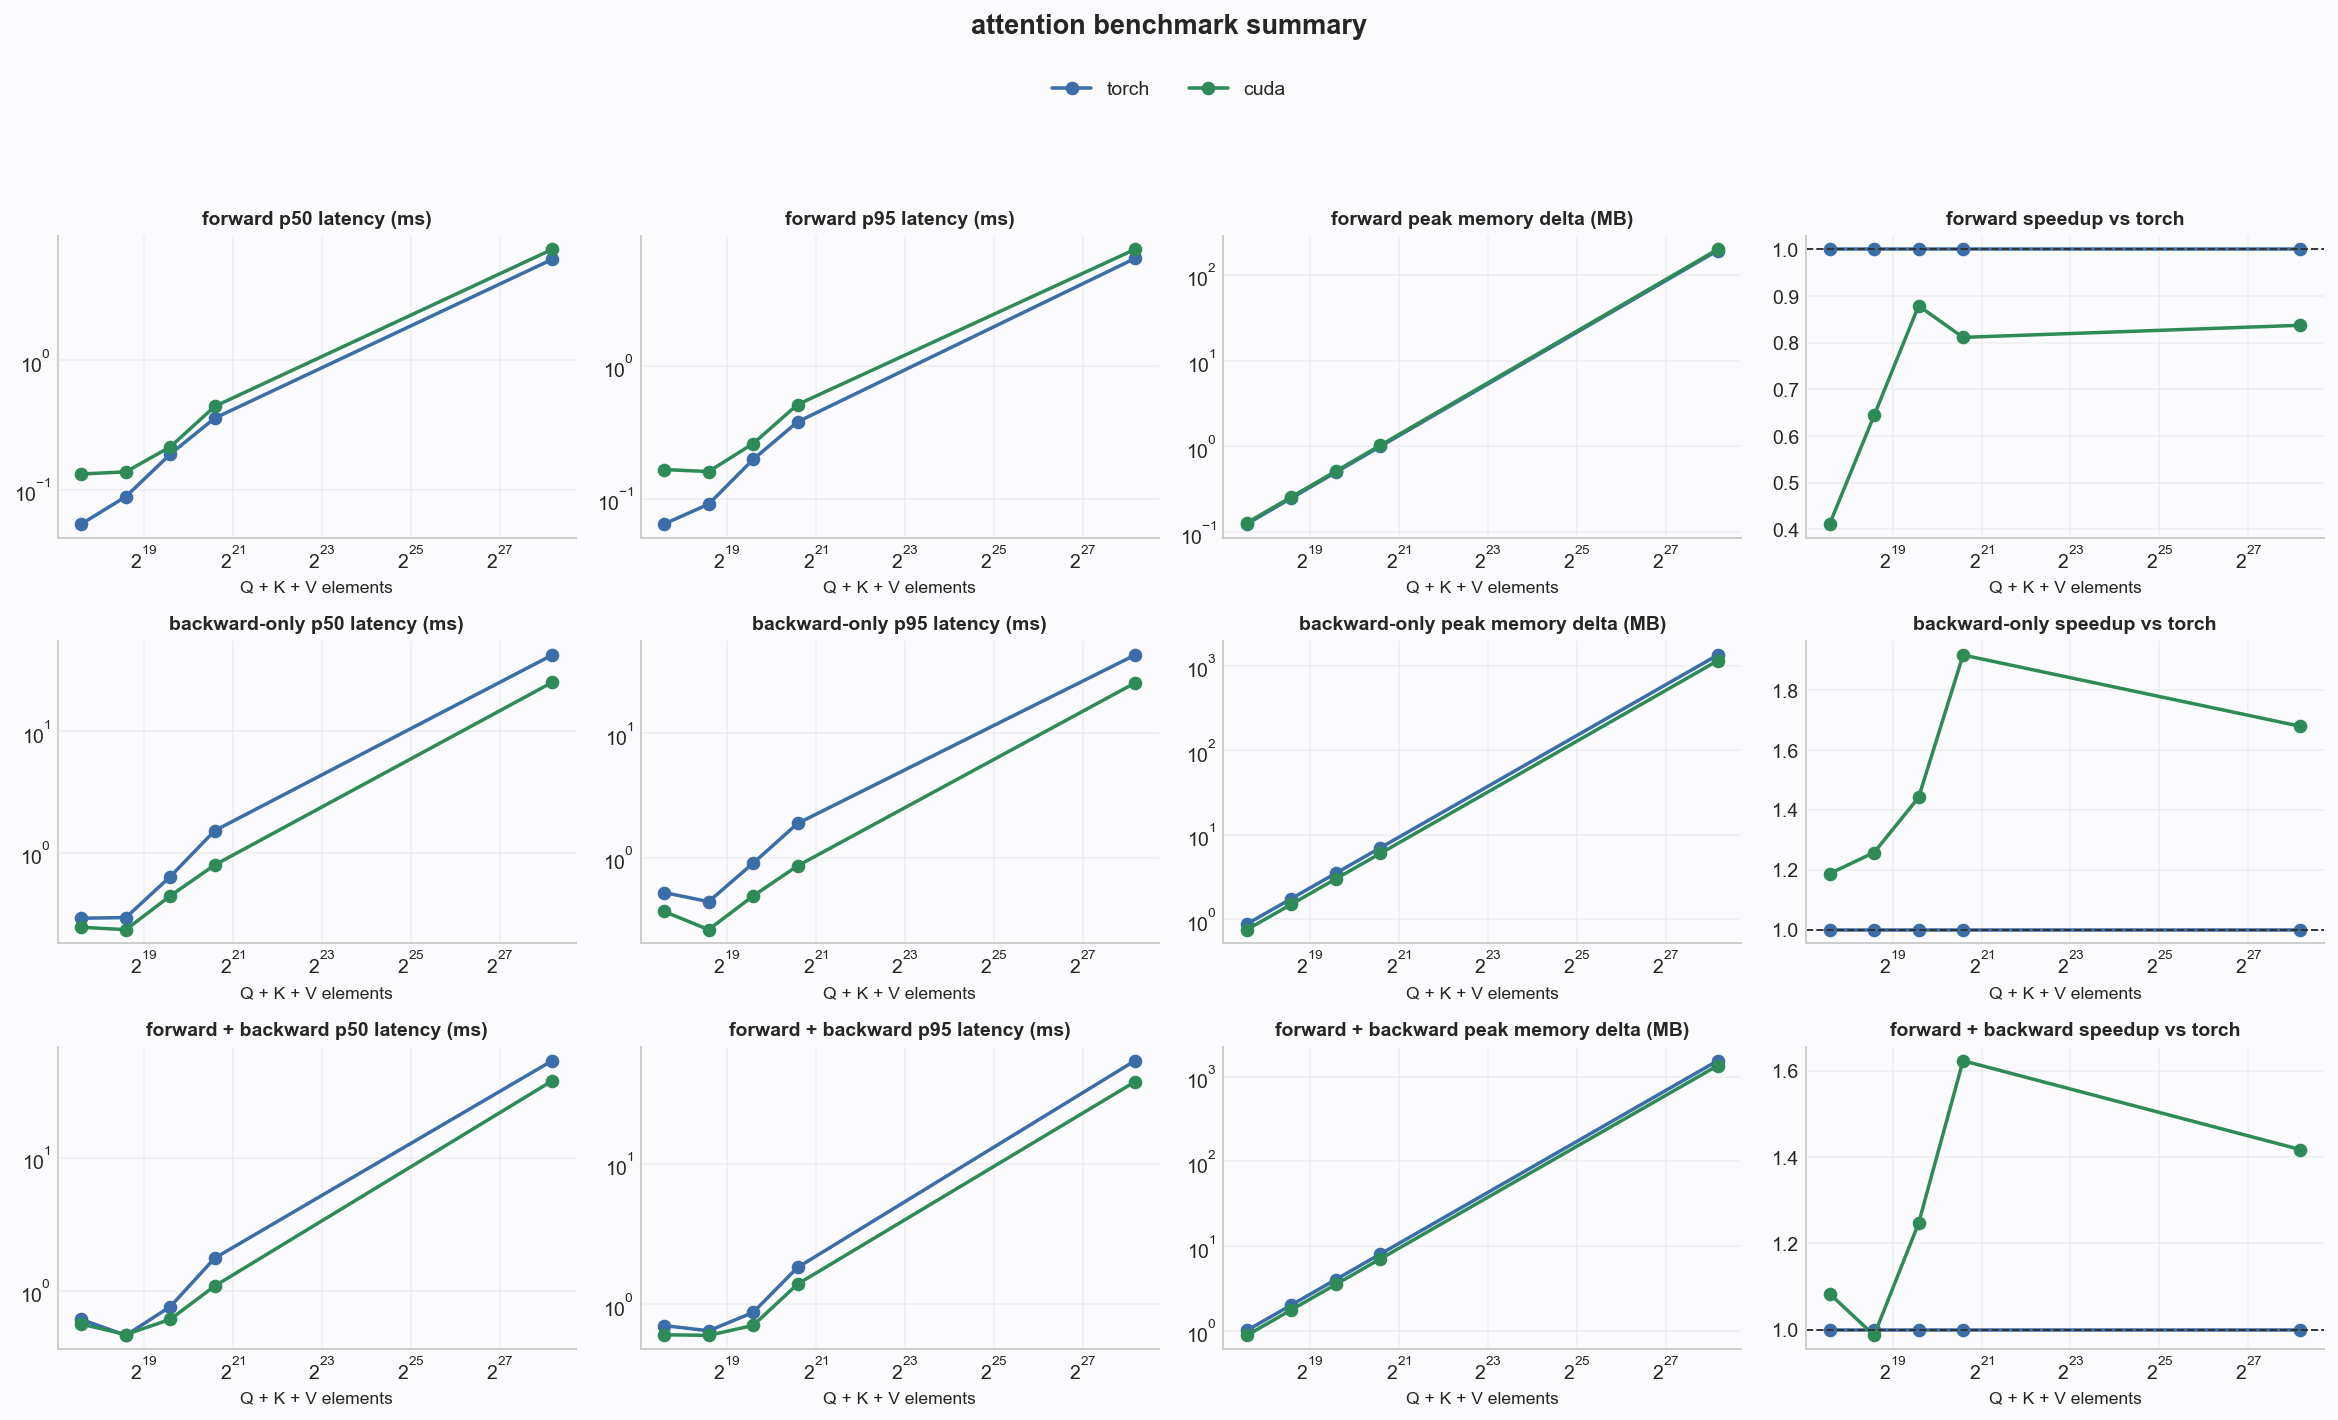

In [9]:
print("CUDA FlashAttention build:", get_cuda_build_config())

attention_sizes = tuple(
    attention_element_count(sequence_length)
    for sequence_length in ATTENTION_SEQUENCE_LENGTHS
) + (ATTENTION_MEMORY_BOUNDARY_SIZE,)
attention_forward = make_attention_forward(
    is_causal=ATTENTION_CAUSAL,
    dropout_p=0.0,
)
report_pytorch_sdpa_backends(attention_sizes, dropout_p=0.0)
attention_rows = run_kernel(
    "attention",
    attention_sizes,
    ATTENTION_SIZE_LABEL,
    make_attention_case,
    attention_forward,
    providers=ATTENTION_PROVIDERS,
    autotune_kernels=flash_attention_autotune_kernels(),
    nsight_size=attention_element_count(128),
    nsight_autotune_kernels=flash_attention_autotune_kernels,
    nsight_provider="cuda",
)

attention_summary = to_summary_dataframe(attention_rows)
attention_failures = attention_summary[attention_summary["status"] != "ok"]
if not attention_failures.empty:
    display(attention_failures[["provider", "size", "status", "error"]])


### Correctness contracts

These checks validate dropout replay, every compiled fp16 bucket, non-contiguous layouts, CUDA streams, and capability boundaries.


In [10]:
@cuda_cleanup
def check_triton_dropout_correctness():
    release_cache()
    try:
        batch, heads, seq, head_dim = 1, 2, 64, 32
        shape = (batch, heads, seq, head_dim)
        q, k, v = (torch.randn(shape, device=DEVICE, dtype=torch.float32) for _ in range(3))
        if not is_triton_flash_attention_supported(
            q, k, v, dropout_p=ATTENTION_DROPOUT_RATE
        ):
            return {"status": "unsupported"}

        seed = torch.tensor(1234567, device=DEVICE, dtype=torch.int32)
        grad_out = torch.randn_like(q)
        out, lse, _, softmax_scale = flash_attention_forward(
            q,
            k,
            v,
            is_causal=ATTENTION_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_RATE,
            dropout_seed=seed,
        )
        keep = flash_attention_dropout_mask(
            batch,
            heads,
            seq,
            seq,
            device=DEVICE,
            dropout_p=ATTENTION_DROPOUT_RATE,
            dropout_seed=seed,
        )

        q_ref, k_ref, v_ref = (tensor.detach().clone().requires_grad_(True) for tensor in (q, k, v))
        scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
        if ATTENTION_CAUSAL:
            positions = torch.arange(seq, device=DEVICE)
            scores = scores.masked_fill(positions[:, None] < positions[None, :], float("-inf"))
        probabilities = torch.softmax(scores, dim=-1)
        reference = (probabilities * keep / (1.0 - ATTENTION_DROPOUT_RATE)) @ v_ref
        reference.backward(grad_out)

        dq, dk, dv = flash_attention_backward(
            grad_out,
            q,
            k,
            v,
            out,
            lse,
            seed,
            is_causal=ATTENTION_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_RATE,
            softmax_scale=softmax_scale,
        )
        torch.cuda.synchronize()

        pairs = {
            "fwd": (out, reference),
            "dq": (dq, q_ref.grad),
            "dk": (dk, k_ref.grad),
            "dv": (dv, v_ref.grad),
        }
        stats = {"status": "ok", "keep_ratio": keep.float().mean().item()}
        for name, (actual, expected) in pairs.items():
            actual, expected = actual.float(), expected.float()
            stats[f"{name}_max_abs"] = (actual - expected).abs().max().item()
            stats[f"{name}_correct"] = torch.allclose(actual, expected, atol=3e-2, rtol=3e-2)
        return stats
    finally:
        release_cache()


In [11]:
@cuda_cleanup
def check_cuda_fp16_correctness():
    """Validate CUDA fp16 buckets and masked tails against an fp32 reference."""

    # Keep the debug problem deliberately small: the helper materializes the S x S
    # dropout matrix solely so PyTorch can replay the CUDA kernel's exact random mask.
    batch, heads, seq = 1, 2, 37
    # Exact bucket boundaries exercise the primary specializations. Values
    # between them exercise uneven-K masked loads/stores in the next bucket.
    head_dims = (32, 40, 64, 80, 96, 128, 160, 192, 200, 256)
    rows = []
    release_cache()
    try:
        for head_dim in head_dims:
            for is_causal in (False, True):
                for dropout_p in (0.0, ATTENTION_DROPOUT_RATE):
                    shape = (batch, heads, seq, head_dim)
                    q, k, v = (
                        torch.randn(shape, device=DEVICE, dtype=torch.float16)
                        for _ in range(3)
                    )
                    row = {
                        "dtype": "fp16",
                        "head_dim": head_dim,
                        "causal": is_causal,
                        "dropout_p": dropout_p,
                    }

                    # The support predicate distinguishes omitted build variants and
                    # hardware limits such as sm86 D256 dropout backward shared memory.
                    if not is_cuda_flash_attention_supported(
                        q, k, v, dropout_p=dropout_p
                    ):
                        row["status"] = "unsupported"
                        rows.append(row)
                        continue

                    grad_out = torch.randn_like(q)

                    # Run the production autograd path first. Resetting the CUDA seed
                    # lets the debug helper reproduce this call's exact Philox mask.
                    seed = 20260713 + head_dim * 10 + int(is_causal)
                    torch.cuda.manual_seed(seed)
                    rng_before = torch.cuda.get_rng_state(q.device)
                    q_cuda, k_cuda, v_cuda = (
                        tensor.detach().clone().requires_grad_(True) for tensor in (q, k, v)
                    )
                    out = get_ops_backend("cuda").attention(
                        q_cuda,
                        k_cuda,
                        v_cuda,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    out.backward(grad_out)
                    rng_after = torch.cuda.get_rng_state(q.device)
                    rng_advanced = not torch.equal(rng_before, rng_after)
                    row["rng_behavior_correct"] = bool(
                        rng_advanced if dropout_p else not rng_advanced
                    )
                    cuda_grads = (q_cuda.grad, k_cuda.grad, v_cuda.grad)

                    # For dropout, read the keep mask produced by the vendored CUDA
                    # kernel. For no-dropout, an all-true mask gives the same formula.
                    if dropout_p:
                        torch.cuda.manual_seed(seed)
                        debug_out, keep = cuda_flash_attention_dropout_mask(
                            q, k, v,
                            is_causal=is_causal,
                            dropout_p=dropout_p,
                        )
                        row["debug_output_equal"] = bool(torch.equal(out, debug_out))
                        row["keep_ratio"] = keep.float().mean().item()
                    else:
                        keep = torch.ones(
                            (batch, heads, seq, seq), device=DEVICE, dtype=torch.bool
                        )
                        row["debug_output_equal"] = True
                        row["keep_ratio"] = 1.0

                    # Compute attention in fp32 so the reference does not silently
                    # select another fused attention implementation in PyTorch SDPA.
                    q_ref, k_ref, v_ref = (
                        tensor.detach().float().requires_grad_(True) for tensor in (q, k, v)
                    )
                    scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
                    if is_causal:
                        causal_mask = torch.ones(
                            (seq, seq), device=DEVICE, dtype=torch.bool
                        ).triu(1)
                        scores = scores.masked_fill(causal_mask, float("-inf"))
                    probabilities = torch.softmax(scores, dim=-1)
                    reference = (
                        probabilities * keep / (1.0 - dropout_p)
                    ) @ v_ref
                    # A scalar sum produces an expanded stride-0 dout in
                    # autograd. Save its fp32 gradients before consuming the
                    # reference graph with the normal random grad_out check.
                    reference_sum_grads = torch.autograd.grad(
                        reference.sum(), (q_ref, k_ref, v_ref), retain_graph=True
                    )
                    reference.backward(grad_out.float())

                    # Report each derivative separately; one aggregate boolean would
                    # hide which side of backward failed when a branch regresses.
                    pairs = {
                        "fwd": (out, reference),
                        "dq": (cuda_grads[0], q_ref.grad),
                        "dk": (cuda_grads[1], k_ref.grad),
                        "dv": (cuda_grads[2], v_ref.grad),
                    }
                    row["status"] = "ok"
                    for name, (actual, expected) in pairs.items():
                        actual = actual.float()
                        expected = expected.float()
                        row[f"{name}_max_abs"] = (actual - expected).abs().max().item()
                        row[f"{name}_correct"] = bool(
                            torch.allclose(actual, expected, atol=3e-2, rtol=3e-2)
                        )

                    # Exercise the adapter's non-contiguous dout conversion for
                    # every branch, using the same Philox mask for dropout.
                    torch.cuda.manual_seed(seed)
                    q_sum, k_sum, v_sum = (
                        tensor.detach().clone().requires_grad_(True)
                        for tensor in (q, k, v)
                    )
                    sum_output = get_ops_backend("cuda").attention(
                        q_sum,
                        k_sum,
                        v_sum,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    sum_output.sum().backward()
                    row["expanded_dout_correct"] = all(
                        torch.allclose(actual.float(), expected, atol=3e-2, rtol=3e-2)
                        for actual, expected in zip(
                            (q_sum.grad, k_sum.grad, v_sum.grad), reference_sum_grads
                        )
                    )
                    row["all_correct"] = (
                        row["debug_output_equal"]
                        and row["rng_behavior_correct"]
                        and row["expanded_dout_correct"]
                        and all(
                            row[f"{name}_correct"]
                            for name in ("fwd", "dq", "dk", "dv")
                        )
                    )
                    rows.append(row)
        torch.cuda.synchronize()
        return rows
    finally:
        release_cache()


In [12]:
@cuda_cleanup
def check_cuda_layout_and_stream():
    """Validate outer strides and launches on a non-default CUDA stream."""

    batch, heads, seq, head_dim = 1, 2, 37, 128
    rows = []
    release_cache()
    try:
        for is_causal in (False, True):
            for dropout_p in (0.0, ATTENTION_DROPOUT_RATE):
                # Start in B,S,H,D and transpose without copying. The resulting
                # B,H,S,D tensors keep stride(-1)==1 but are not contiguous.
                physical_shape = (batch, seq, heads, head_dim)
                q, k, v = (
                    torch.randn(
                        physical_shape, device=DEVICE, dtype=torch.float16
                    ).transpose(1, 2)
                    for _ in range(3)
                )
                row = {
                    "dtype": "fp16",
                    "head_dim": head_dim,
                    "causal": is_causal,
                    "dropout_p": dropout_p,
                    "input_stride": tuple(q.stride()),
                    "outer_noncontiguous": (
                        not q.is_contiguous() and q.stride(-1) == 1
                    ),
                }
                if not is_cuda_flash_attention_supported(
                    q, k, v, dropout_p=dropout_p
                ):
                    row["status"] = "unsupported"
                    rows.append(row)
                    continue

                grad_out = torch.randn_like(q)
                seed = 20260713 + int(is_causal)
                stream = torch.cuda.Stream(device=q.device)
                torch.cuda.synchronize(q.device)

                # Keep forward, backward, and debug-mask extraction on the same
                # explicit stream. Synchronize that stream only before CPU checks.
                with torch.cuda.stream(stream):
                    torch.cuda.manual_seed(seed)
                    q_cuda, k_cuda, v_cuda = (
                        tensor.detach().clone().requires_grad_(True)
                        for tensor in (q, k, v)
                    )
                    out = get_ops_backend("cuda").attention(
                        q_cuda,
                        k_cuda,
                        v_cuda,
                        is_causal=is_causal,
                        dropout_p=dropout_p,
                    )
                    out.backward(grad_out)
                    cuda_grads = (q_cuda.grad, k_cuda.grad, v_cuda.grad)
                    if dropout_p:
                        torch.cuda.manual_seed(seed)
                        debug_out, keep = cuda_flash_attention_dropout_mask(
                            q,
                            k,
                            v,
                            is_causal=is_causal,
                            dropout_p=dropout_p,
                        )
                    else:
                        debug_out = out
                        keep = torch.ones(
                            (batch, heads, seq, seq),
                            device=DEVICE,
                            dtype=torch.bool,
                        )
                    completion = torch.cuda.Event()
                    completion.record(stream)
                completion.synchronize()

                # Build the reference after stream completion. It consumes the
                # exact CUDA keep mask but uses explicit fp32 matmul/softmax.
                q_ref, k_ref, v_ref = (
                    tensor.detach().float().requires_grad_(True)
                    for tensor in (q, k, v)
                )
                scores = q_ref @ k_ref.transpose(-1, -2) / math.sqrt(head_dim)
                if is_causal:
                    causal_mask = torch.ones(
                        (seq, seq), device=DEVICE, dtype=torch.bool
                    ).triu(1)
                    scores = scores.masked_fill(causal_mask, float("-inf"))
                reference = (
                    torch.softmax(scores, dim=-1)
                    * keep
                    / (1.0 - dropout_p)
                ) @ v_ref
                reference.backward(grad_out.float())

                pairs = {
                    "fwd": (out, reference),
                    "dq": (cuda_grads[0], q_ref.grad),
                    "dk": (cuda_grads[1], k_ref.grad),
                    "dv": (cuda_grads[2], v_ref.grad),
                }
                row.update(
                    status="ok",
                    stream_id=stream.cuda_stream,
                    kernel_input_stride=tuple(q_cuda.stride()),
                    kernel_outer_noncontiguous=(
                        not q_cuda.is_contiguous() and q_cuda.stride(-1) == 1
                    ),
                    output_stride=tuple(out.stride()),
                    debug_output_equal=bool(torch.equal(out, debug_out)),
                )
                for name, (actual, expected) in pairs.items():
                    row[f"{name}_correct"] = bool(
                        torch.allclose(
                            actual.float(), expected, atol=3e-2, rtol=3e-2
                        )
                    )
                row["all_correct"] = (
                    row["outer_noncontiguous"]
                    and row["kernel_outer_noncontiguous"]
                    and row["debug_output_equal"]
                    and all(
                        row[f"{name}_correct"]
                        for name in ("fwd", "dq", "dk", "dv")
                    )
                )
                rows.append(row)
        return rows
    finally:
        release_cache()


In [13]:
@cuda_cleanup
def check_cuda_capability_contract():
    """Check no-load CUDA capability boundaries for the active build."""

    config = get_cuda_build_config()
    capability = torch.cuda.get_device_capability(DEVICE)
    batch, heads, seq = 1, 2, 7

    # Build one valid control and derive the expected result from the active
    # profile. A larger linked bucket can serve a smaller multiple-of-8 D.
    def build_has(head_dim):
        return (
            "fp16" in config.dtypes
            and any(head_dim <= bucket for bucket in config.head_dims)
            and capability[0] >= 8
        )

    def tensors(shape, *, dtype=torch.float16):
        return tuple(
            torch.randn(shape, device=DEVICE, dtype=dtype) for _ in range(3)
        )

    valid = tensors((batch, heads, seq, 128))
    d200 = tensors((batch, heads, seq, 200))
    # Reproduce the public 144-KiB hardware contract independently. Older
    # PyTorch versions omit the opt-in field, so use the same audited CUDA
    # architecture facts while keeping the threshold comparison visible.
    properties = torch.cuda.get_device_properties(DEVICE)
    optin_smem = next((
        int(getattr(properties, name))
        for name in (
            "shared_memory_per_block_optin",
            "max_shared_memory_per_block_optin",
        )
        if getattr(properties, name, None) is not None
    ), {
        (8, 0): 163 * 1024, (8, 6): 99 * 1024,
        (8, 7): 163 * 1024, (8, 9): 99 * 1024,
        (9, 0): 227 * 1024,
    }.get(capability))
    d200_dropout_expected = (
        build_has(200)
        and optin_smem is not None
        and optin_smem >= 144 * 1024
    )

    # Every invalid case must be rejected before load_cuda_extension(). The
    # two controls track profile and hardware-dependent support explicitly.
    cases = [
        ("valid_d128", valid, 0.0, build_has(128)),
        ("empty_batch", tensors((0, heads, seq, 128)), 0.0, False),
        ("empty_heads", tensors((batch, 0, seq, 128)), 0.0, False),
        ("empty_sequence", tensors((batch, heads, 0, 128)), 0.0, False),
        ("fp32_dtype", tensors((batch, heads, seq, 128), dtype=torch.float32), 0.0, False),
        ("head_dim_not_multiple_of_8", tensors((batch, heads, seq, 130)), 0.0, False),
        ("head_dim_over_256", tensors((batch, heads, seq, 264)), 0.0, False),
        ("dropout_out_of_range", valid, 1.0, False),
        ("dropout_rounds_to_float32_one", valid, 1.0 - 1e-12, False),
        ("dropout_underflows_to_float32_zero", valid, 1e-50, build_has(128)),
        ("d200_dropout_control", d200, ATTENTION_DROPOUT_RATE, d200_dropout_expected),
    ]

    # Construct shape and stride violations separately so only one contract
    # changes in each row. Slicing every other D keeps shape 128, stride 2.
    mismatch = list(valid)
    mismatch[1] = tensors((batch, heads, seq + 1, 128))[1]
    cases.append(("shape_mismatch", tuple(mismatch), 0.0, False))
    noncontiguous = tuple(
        tensor[..., ::2] for tensor in tensors((batch, heads, seq, 256))
    )
    cases.append(("head_dim_stride_2", noncontiguous, 0.0, False))

    rows = []
    for name, (q, k, v), dropout_p, expected in cases:
        actual = is_cuda_flash_attention_supported(
            q, k, v, dropout_p=dropout_p
        )
        rows.append(
            {
                "case": name,
                "shape": tuple(q.shape),
                "last_stride": q.stride(-1),
                "dropout_p": dropout_p,
                "supported": actual,
                "expected": expected,
                "correct": actual == expected,
            }
        )
    return rows


### Dropout validation and sequence-length sweep

Supported branches must pass correctness before timings are reported.


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-dropout-triton-correctness\2026-07-15T17-59-15.136834_00-00.json
raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-cuda-fp16-correctness\2026-07-15T17-59-15.138836_00-00.json
raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-cuda-layout-stream-correctness\2026-07-15T17-59-15.141971_00-00.json
raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-cuda-capability-contract\2026-07-15T17-59-15.143978_00-00.json


,dtype,head_dim,causal,dropout_p,rng_behavior_correct,debug_output_equal,keep_ratio,status,fwd_max_abs,fwd_correct,dq_max_abs,dq_correct,dk_max_abs,dk_correct,dv_max_abs,dv_correct,expanded_dout_correct,all_correct
0,fp16,32,False,0.0,True,True,1.000000,ok,0.000454,True,0.000477,True,0.000612,True,0.000552,True,True,True
1,fp16,32,False,0.1,True,True,0.889335,ok,0.000454,True,0.000455,True,0.000373,True,0.000426,True,True,True
2,fp16,32,True,0.0,True,True,1.000000,ok,0.000609,True,0.000909,True,0.000990,True,0.000941,True,True,True
3,fp16,32,True,0.1,True,True,0.902118,ok,0.000868,True,0.000829,True,0.001292,True,0.001554,True,True,True
4,fp16,40,False,0.0,True,True,1.000000,ok,0.000340,True,0.000319,True,0.000428,True,0.000630,True,True,True
5,fp16,40,False,0.1,True,True,0.897005,ok,0.000397,True,0.000599,True,0.000656,True,0.000545,True,True,True
6,fp16,40,True,0.0,True,True,1.000000,ok,0.000750,True,0.001656,True,0.000956,True,0.000920,True,True,True
7,fp16,40,True,0.1,True,True,0.908693,ok,0.000868,True,0.000929,True,0.001783,True,0.001456,True,True,True
8,fp16,64,False,0.0,True,True,1.000000,ok,0.000464,True,0.000901,True,0.000695,True,0.000537,True,True,True
9,fp16,64,False,0.1,True,True,0.909423,ok,0.000406,True,0.000689,True,0.000814,True,0.000675,True,True,True


,dtype,head_dim,causal,dropout_p,input_stride,outer_noncontiguous,status,stream_id,kernel_input_stride,kernel_outer_noncontiguous,output_stride,debug_output_equal,fwd_correct,dq_correct,dk_correct,dv_correct,all_correct
0,fp16,128,False,0.0,"(9472, 128, 256, 1)",True,ok,2314789640784,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
1,fp16,128,False,0.1,"(9472, 128, 256, 1)",True,ok,2314789642032,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
2,fp16,128,True,0.0,"(9472, 128, 256, 1)",True,ok,2314789641968,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True
3,fp16,128,True,0.1,"(9472, 128, 256, 1)",True,ok,2314789641808,"(9472, 128, 256, 1)",True,"(9472, 128, 256, 1)",True,True,True,True,True,True


,case,shape,last_stride,dropout_p,supported,expected,correct
0,valid_d128,"(1, 2, 7, 128)",1,0.000000e+00,True,True,True
1,empty_batch,"(0, 2, 7, 128)",1,0.000000e+00,False,False,True
2,empty_heads,"(1, 0, 7, 128)",1,0.000000e+00,False,False,True
3,empty_sequence,"(1, 2, 0, 128)",1,0.000000e+00,False,False,True
4,fp32_dtype,"(1, 2, 7, 128)",1,0.000000e+00,False,False,True
5,head_dim_not_multiple_of_8,"(1, 2, 7, 130)",1,0.000000e+00,False,False,True
6,head_dim_over_256,"(1, 2, 7, 264)",1,0.000000e+00,False,False,True
7,dropout_out_of_range,"(1, 2, 7, 128)",1,1.000000e+00,False,False,True
8,dropout_rounds_to_float32_one,"(1, 2, 7, 128)",1,1.000000e+00,False,False,True
9,dropout_underflows_to_float32_zero,"(1, 2, 7, 128)",1,1.000000e-50,True,True,True


CUDA fp16 correctness: 24 supported, 16 unsupported, 0 failed


,status,dropout_p,keep_ratio
0,unsupported,0.1,None


,check,correct,max_abs
0,fwd,None,None
1,dq,None,None
2,dk,None,None
3,dv,None,None


PyTorch SDPA backend selection (causal=True, dropout_p=0.1):
  shape=(1, 4, 256, 64) -> memory_efficient_attention
  shape=(1, 4, 512, 64) -> memory_efficient_attention
  shape=(1, 4, 1024, 64) -> memory_efficient_attention
  shape=(1, 4, 2048, 64) -> memory_efficient_attention
  shape=(1536, 4, 256, 64) -> memory_efficient_attention
raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-dropout\2026-07-15T17-59-37.069554_00-00.json


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup,full_p50_ms,full_p95_ms,full_peak_mem_mb,full_speedup,error
0,attention_dropout,torch,196608,ok,True,True,0.072192,0.170086,0.125000,1.000000,0.511920,0.619611,0.879883,1.000000,NaN,NaN,NaN,NaN,NaN
1,attention_dropout,triton,196608,unavailable,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
2,attention_dropout,cuda,196608,ok,True,True,0.134144,0.155088,0.129395,0.538168,0.246784,0.390038,0.754395,2.074365,NaN,NaN,NaN,NaN,NaN
3,attention_dropout,torch,393216,ok,True,True,0.112640,0.114893,0.250000,1.000000,0.447920,0.559565,1.758789,1.000000,NaN,NaN,NaN,NaN,NaN
4,attention_dropout,triton,393216,unavailable,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
5,attention_dropout,cuda,393216,ok,True,True,0.137728,0.152976,0.258301,0.817844,0.244736,0.350514,1.508301,1.830217,NaN,NaN,NaN,NaN,NaN
6,attention_dropout,torch,786432,ok,True,True,0.265728,0.284653,0.500000,1.000000,0.727040,0.882578,3.517090,1.000000,NaN,NaN,NaN,NaN,NaN
7,attention_dropout,triton,786432,unavailable,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RuntimeError: triton does not support this att...
8,attention_dropout,cuda,786432,ok,True,True,0.214016,0.256973,0.516113,1.241627,0.457216,0.502579,3.016113,1.590146,NaN,NaN,NaN,NaN,NaN
9,attention_dropout,torch,1572864,ok,True,True,0.553472,0.568371,1.000000,1.000000,2.188800,2.242918,7.033691,1.000000,NaN,NaN,NaN,NaN,NaN


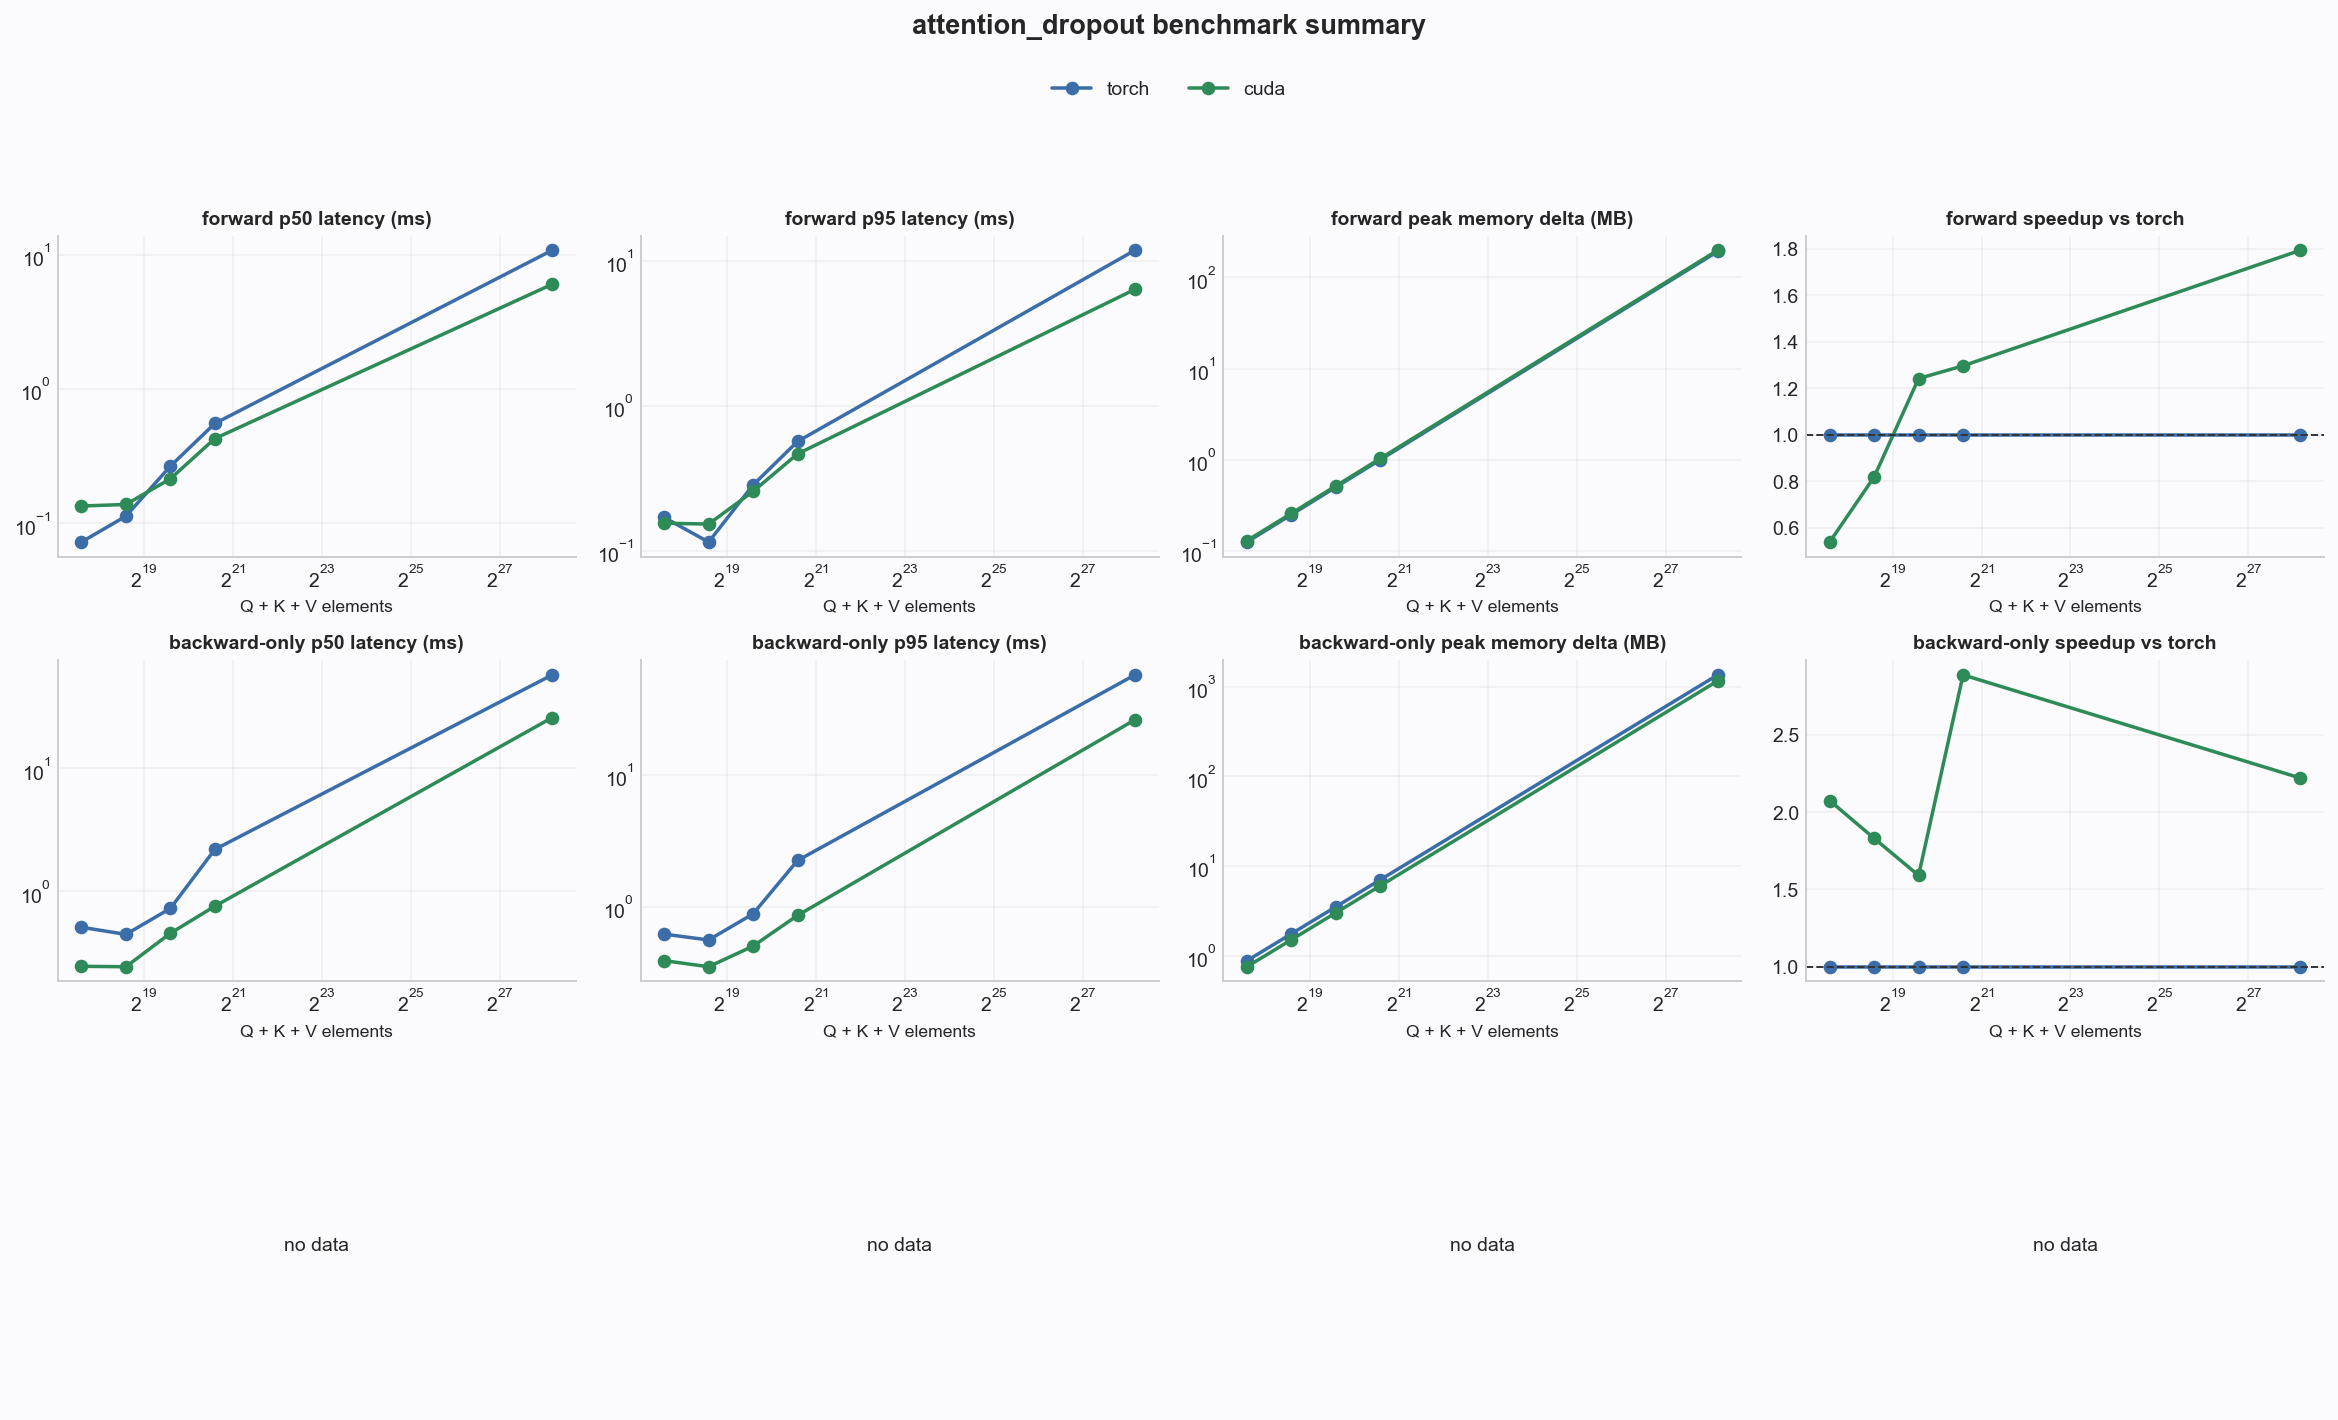

In [14]:
triton_dropout_check = check_triton_dropout_correctness()
cuda_fp16_check_rows = check_cuda_fp16_correctness()
cuda_layout_stream_check_rows = check_cuda_layout_and_stream()
cuda_capability_check_rows = check_cuda_capability_contract()

cache_benchmark_rows(
    "attention_dropout_triton_correctness",
    [triton_dropout_check],
    dataset_type="correctness",
)
cache_benchmark_rows(
    "attention_cuda_fp16_correctness",
    cuda_fp16_check_rows,
    dataset_type="correctness",
)
cache_benchmark_rows(
    "attention_cuda_layout_stream_correctness",
    cuda_layout_stream_check_rows,
    dataset_type="correctness",
)
cache_benchmark_rows(
    "attention_cuda_capability_contract",
    cuda_capability_check_rows,
    dataset_type="correctness",
)

cuda_fp16_check_frame = pd.DataFrame(cuda_fp16_check_rows)
display(cuda_fp16_check_frame)
display(pd.DataFrame(cuda_layout_stream_check_rows))
display(pd.DataFrame(cuda_capability_check_rows))

cuda_fp16_failures = cuda_fp16_check_frame[
    (cuda_fp16_check_frame["status"] == "ok")
    & (cuda_fp16_check_frame["all_correct"] != True)
]
layout_stream_failures = [
    row for row in cuda_layout_stream_check_rows if not row["all_correct"]
]
capability_failures = [
    row for row in cuda_capability_check_rows if not row["correct"]
]

print(
    "CUDA fp16 correctness: "
    f"{(cuda_fp16_check_frame['status'] == 'ok').sum()} supported, "
    f"{(cuda_fp16_check_frame['status'] == 'unsupported').sum()} unsupported, "
    f"{len(cuda_fp16_failures)} failed"
)
if not cuda_fp16_failures.empty:
    display(cuda_fp16_failures)

# Supported branches are executable tests: invalid timings must never enter reports.
assert cuda_fp16_failures.empty, (
    f"CUDA fp16 numerical failures: {len(cuda_fp16_failures)}"
)
assert not layout_stream_failures, (
    f"CUDA layout/stream failures: {layout_stream_failures}"
)
assert not capability_failures, (
    f"CUDA capability failures: {capability_failures}"
)

cuda_dropout_rows = [
    row
    for row in cuda_fp16_check_rows
    if row["status"] == "ok" and row["dropout_p"] == ATTENTION_DROPOUT_RATE
]
dropout_correctness = {
    "torch": {"fwd_correct": True, "bwd_correct": True},
    "triton": {
        "fwd_correct": triton_dropout_check.get("fwd_correct", False),
        "bwd_correct": all(
            triton_dropout_check.get(f"{name}_correct", False)
            for name in ("dq", "dk", "dv")
        ),
    },
    "cuda": {
        "fwd_correct": bool(cuda_dropout_rows) and all(
            row["fwd_correct"]
            and row["debug_output_equal"]
            and row["rng_behavior_correct"]
            for row in cuda_dropout_rows
        ),
        "bwd_correct": bool(cuda_dropout_rows) and all(
            row[name]
            for row in cuda_dropout_rows
            for name in ("dq_correct", "dk_correct", "dv_correct")
        ),
    },
}

display(pd.DataFrame([{
    "status": triton_dropout_check.get("status"),
    "dropout_p": ATTENTION_DROPOUT_RATE,
    "keep_ratio": triton_dropout_check.get("keep_ratio"),
}]))
display(pd.DataFrame([
    {
        "check": name,
        "correct": triton_dropout_check.get(f"{name}_correct"),
        "max_abs": triton_dropout_check.get(f"{name}_max_abs"),
    }
    for name in ("fwd", "dq", "dk", "dv")
]))

attention_dropout_forward = make_attention_forward(
    is_causal=ATTENTION_CAUSAL,
    dropout_p=ATTENTION_DROPOUT_RATE,
)
register_nsight_kernel(
    "attention_dropout",
    make_attention_case,
    attention_dropout_forward,
    default_size=attention_element_count(128),
    provider="cuda",
    autotune_kernels=flash_attention_autotune_kernels,
)
report_pytorch_sdpa_backends(attention_sizes, dropout_p=ATTENTION_DROPOUT_RATE)

attention_dropout_rows = [
    row
    for size in attention_sizes
    for row in benchmark_attention_case(
        kernel="attention_dropout",
        size=size,
        make_case=make_attention_case,
        forward=attention_dropout_forward,
        correctness=dropout_correctness,
    )
]
cache_benchmark_rows(
    "attention_dropout",
    attention_dropout_rows,
    providers=ATTENTION_PROVIDERS,
    sequence_lengths=ATTENTION_SEQUENCE_LENGTHS,
    dropout_p=ATTENTION_DROPOUT_RATE,
)
display_triton_config_summary(attention_dropout_rows)
display(to_summary_dataframe(attention_dropout_rows))
_ = plot_kernel_grid(
    attention_dropout_rows,
    metrics=METRICS,
    save_path=FIG_DIR / "attention_dropout_summary.png",
)


### CUDA fp16 specialization matrix

This fixes sequence length at 1024 and traverses every compiled head-dimension, causal, and dropout branch.


In [15]:
# Fixed-S matrix: every compiled fp16 head-dimension, causal, and dropout branch.
CUDA_MATRIX_BATCH_SIZE = 1
CUDA_MATRIX_NUM_HEADS = 4
CUDA_MATRIX_SEQUENCE_LENGTH = 512
CUDA_MATRIX_HEAD_DIMS = (32, 64, 96, 128, 192, 256)
CUDA_MATRIX_CAUSAL_OPTIONS = (False, True)
CUDA_MATRIX_DROPOUT_RATES = (0.0, ATTENTION_DROPOUT_RATE)


def make_cuda_matrix_case(size, *, head_dim):
    return make_attention_case(
        size,
        batch_size=CUDA_MATRIX_BATCH_SIZE,
        num_heads=CUDA_MATRIX_NUM_HEADS,
        head_dim=head_dim,
        dtype=torch.float16,
    )


@cuda_cleanup
def run_cuda_fp16_performance_matrix():
    correctness_index = {
        (row["head_dim"], row["causal"], row["dropout_p"]): row
        for row in cuda_fp16_check_rows
    }
    rows = []

    branches = product(
        CUDA_MATRIX_HEAD_DIMS,
        CUDA_MATRIX_CAUSAL_OPTIONS,
        CUDA_MATRIX_DROPOUT_RATES,
    )
    for head_dim, is_causal, dropout_p in branches:
        size = attention_element_count(
            CUDA_MATRIX_SEQUENCE_LENGTH,
            batch_size=CUDA_MATRIX_BATCH_SIZE,
            num_heads=CUDA_MATRIX_NUM_HEADS,
            head_dim=head_dim,
        )
        make_case = partial(make_cuda_matrix_case, head_dim=head_dim)
        forward = make_attention_forward(
            is_causal=is_causal,
            dropout_p=dropout_p,
        )

        probe = make_case(size)
        try:
            supported = attention_provider_support(
                probe.tensors,
                dropout_p=dropout_p,
            )
        finally:
            probe.tensors.clear()
            release_cache()

        branch_check = correctness_index[(head_dim, is_causal, dropout_p)]
        correctness = {
            "cuda": {
                "fwd_correct": branch_check.get("fwd_correct"),
                "bwd_correct": all(
                    branch_check.get(name, False)
                    for name in ("dq_correct", "dk_correct", "dv_correct")
                ),
            }
        }
        rows.extend(
            benchmark_attention_case(
                kernel="attention_fp16_matrix",
                size=size,
                make_case=make_case,
                forward=forward,
                metadata={
                    "dtype": "fp16",
                    "head_dim": head_dim,
                    "sequence": CUDA_MATRIX_SEQUENCE_LENGTH,
                    "causal": is_causal,
                    "dropout_p": dropout_p,
                },
                correctness=correctness,
                supported=supported,
            )
        )
    return rows


cuda_fp16_performance_rows = run_cuda_fp16_performance_matrix()
cache_benchmark_rows(
    "attention_fp16_matrix",
    cuda_fp16_performance_rows,
    providers=ATTENTION_PROVIDERS,
    sequence_length=CUDA_MATRIX_SEQUENCE_LENGTH,
    head_dims=CUDA_MATRIX_HEAD_DIMS,
    causal_options=CUDA_MATRIX_CAUSAL_OPTIONS,
    dropout_rates=CUDA_MATRIX_DROPOUT_RATES,
)
display_triton_config_summary(cuda_fp16_performance_rows)
cuda_fp16_performance_frame = pd.DataFrame(cuda_fp16_performance_rows)
cuda_fp16_performance_columns = (
    "dtype", "head_dim", "sequence", "causal", "dropout_p",
    "provider", "status", "fwd_correct", "bwd_correct",
    "fwd_p50_ms", "fwd_p95_ms", "fwd_peak_mem_mb", "fwd_speedup",
    "bwd_p50_ms", "bwd_p95_ms", "bwd_peak_mem_mb", "bwd_speedup",
    "error",
)
display(cuda_fp16_performance_frame[[
    column
    for column in cuda_fp16_performance_columns
    if column in cuda_fp16_performance_frame.columns
]])


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\attention-fp16-matrix\2026-07-15T18-00-58.600494_00-00.json


,dtype,head_dim,sequence,causal,dropout_p,provider,status,fwd_correct,bwd_correct,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,fp16,32,512,False,0.0,torch,ok,NaN,NaN,0.069600,0.088003,0.125000,1.000000,0.367184,0.401664,1.133789,1.000000
1,fp16,32,512,False,0.0,triton,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fp16,32,512,False,0.0,cuda,ok,True,True,0.209856,0.224710,0.132812,0.331656,0.357376,0.411341,0.758301,1.027444
3,fp16,32,512,False,0.1,torch,ok,NaN,NaN,0.108496,0.109670,0.125000,1.000000,0.308640,0.454605,1.133789,1.000000
4,fp16,32,512,False,0.1,triton,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,fp16,256,512,True,0.0,triton,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,fp16,256,512,True,0.0,cuda,unsupported,None,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,fp16,256,512,True,0.1,torch,ok,NaN,NaN,0.207872,0.212122,3.000000,1.000000,1.491408,1.902949,11.009277,1.000000
70,fp16,256,512,True,0.1,triton,unsupported,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Nsight Compute

The call below profiles one backward pass at sequence length 128 in a clean worker process. It writes both `.ncu-rep` and `.csv` reports under the active GPU's `tests/benchmark_results/<gpu>/nsight` directory.


In [16]:
try:
    attention_nsight = profile_and_cache_kernel(
        "attention",
        mode="bwd",
        size=attention_element_count(128),
        sections=("LaunchStats",),
        timeout_s=120,
    )
except PermissionError as error:
    print(error)


,kernel,mode,size,report_prefix,report,csv,command,kernels_captured,kernels_displayed,launch_count,launch_skip_before_match,kernel_filter,capture_kernel_filter,capture_mode,use_nvtx,nvtx_include
0,attention,bwd,98304,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,[C:\Program Files\NVIDIA Corporation\Nsight Co...,5,5,128,0,None,None,cuda_profiler,False,None


,Kernel Name,Context,Stream,Registers Per Thread,Block Size,Grid Size
0,void at::native::vectorized_elementwise_kernel...,1,7,16 register/thread,128,1
1,"void at::native::elementwise_kernel<(int)128, ...",1,7,32 register/thread,128,64
2,void minitrain_flash::flash_bwd_dot_do_o_kerne...,1,7,40 register/thread,256,8
3,void minitrain_flash::flash_bwd_dq_dk_dv_loop_...,1,7,255 register/thread,256,4
4,void minitrain_flash::flash_bwd_convert_dq_ker...,1,7,40 register/thread,256,8


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\nsight-attention-bwd-98304\2026-07-15T18-01-17.013842_00-00.json


### Nsight Compute (standalone)

This block uses the same registration path as `run_kernel`, but it only registers a small FlashAttention case for Nsight. It does not run the benchmark sweep.


In [17]:
import torch

from minitrain.kernels.triton.flash_attention import flash_attention_autotune_kernels
from minitrain.model.ops import get_ops_backend
from operator_bench_utils import BenchCase

STANDALONE_ATTENTION_BATCH = 1
STANDALONE_ATTENTION_HEADS = 4
STANDALONE_ATTENTION_HEAD_DIM = 128
STANDALONE_ATTENTION_CAUSAL = True
STANDALONE_ATTENTION_DROPOUT_P = 0.0
STANDALONE_ATTENTION_DEVICE = torch.device("cuda")
STANDALONE_ATTENTION_DTYPE = DTYPE


def standalone_attention_size(seq):
    return (
        3
        * STANDALONE_ATTENTION_BATCH
        * STANDALONE_ATTENTION_HEADS
        * seq
        * STANDALONE_ATTENTION_HEAD_DIM
    )


def make_standalone_attention_case(size):
    seq = size // (
        3
        * STANDALONE_ATTENTION_BATCH
        * STANDALONE_ATTENTION_HEADS
        * STANDALONE_ATTENTION_HEAD_DIM
    )
    shape = (
        STANDALONE_ATTENTION_BATCH,
        STANDALONE_ATTENTION_HEADS,
        seq,
        STANDALONE_ATTENTION_HEAD_DIM,
    )
    return BenchCase(
        tensors={
            name: torch.randn(
                shape,
                device=STANDALONE_ATTENTION_DEVICE,
                dtype=STANDALONE_ATTENTION_DTYPE,
            )
            for name in ("q", "k", "v")
        },
        grad_names=("q", "k", "v"),
    )


def standalone_attention_forward(provider, tensors):
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=STANDALONE_ATTENTION_CAUSAL,
        dropout_p=STANDALONE_ATTENTION_DROPOUT_P,
    )


standalone_attention_sizes = (standalone_attention_size(8*1024),)
register_kernel(
    "standalone_attention",
    standalone_attention_sizes,
    "Q + K + V elements",
    make_standalone_attention_case,
    standalone_attention_forward,
    nsight_size=standalone_attention_size(8*1024),
    nsight_autotune_kernels=flash_attention_autotune_kernels,
    nsight_provider="cuda",
)

# Example: uncomment one line when you want to generate a small report.
# standalone_attention_report = profile_and_cache_kernel("standalone_attention", mode="fwd", timeout_s=120)
standalone_attention_bwd_report = profile_and_cache_kernel(
    "standalone_attention",
    mode="bwd",
    timeout_s=300,
    launch_count=32,
    kernel_filter="flash_bwd",
    capture_kernel_filter=".*flash_bwd.*",
    capture_mode="cuda_profiler",
)


,kernel,mode,size,report_prefix,report,csv,command,kernels_captured,kernels_displayed,launch_count,launch_skip_before_match,kernel_filter,capture_kernel_filter,capture_mode,use_nvtx,nvtx_include
0,standalone_attention,bwd,12582912,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-...,[C:\Program Files\NVIDIA Corporation\Nsight Co...,3,3,32,0,flash_bwd,.*flash_bwd.*,cuda_profiler,False,None


,Kernel Name,Context,Stream,Registers Per Thread,Block Size,Grid Size
0,void minitrain_flash::flash_bwd_dot_do_o_kerne...,1,7,48 register/thread,256,512
1,void minitrain_flash::flash_bwd_dq_dk_dv_loop_...,1,7,255 register/thread,256,512
2,void minitrain_flash::flash_bwd_convert_dq_ker...,1,7,56 register/thread,256,512


raw benchmark data: C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\nsight-standalone-attention-bwd-12582912\2026-07-15T18-01-34.373622_00-00.json


### Some debug tools

In [18]:
# find all unique kernel names in the report
import pandas as pd
kernel_summary = pd.DataFrame(standalone_attention_bwd_report["summary_all"])
kernel_name_column = next(
    (name for name in ("Kernel Name", "KernelName") if name in kernel_summary),
    None,
)
if kernel_name_column is None:
    raise KeyError(f"Nsight summary has no kernel-name column: {list(kernel_summary)}")
kernel_summary[[kernel_name_column]].drop_duplicates()

,Kernel Name
0,void minitrain_flash::flash_bwd_dot_do_o_kerne...
1,void minitrain_flash::flash_bwd_dq_dk_dv_loop_...
2,void minitrain_flash::flash_bwd_convert_dq_ker...


In [19]:
# check the GPU properties and capabilities
def get_prop(props, *names):
    for name in names:
        if hasattr(props, name):
            return getattr(props, name)
    return None

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

print(torch.cuda.get_device_capability(0))

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}: {props}")
    # print(f"\nGPU {i}: {props.name}")
    # print("compute capability:", props.major, props.minor)
    # print("total memory GB:", props.total_memory / 1024**3)
    # print("multi processor count:",
    # props.multi_processor_count)
    # print("warp size:", get_prop(props, "warp_size"))
    # print("max threads per block:", get_prop(props,
    # "max_threads_per_block"))
    # print("max threads per multiprocessor:", get_prop(props,
    # "max_threads_per_multiprocessor"))

    # print("registers per block:", get_prop(props,
    # "regs_per_block"))
    # print("registers per multiprocessor:", get_prop(props,
    # "regs_per_multiprocessor"))

    # smem_block = get_prop(
    #     props,
    #     "shared_memory_per_block",
    #     "shared_memory_per_block_optin",
    # )
    # smem_sm = get_prop(
    #     props,
    #     "shared_memory_per_multiprocessor",
    #     "shared_memory_per_sm",
    # )

    # print("shared memory per block KB:", None if smem_block
    # is None else smem_block / 1024)
    # print("shared memory per multiprocessor KB:", None if
    # smem_sm is None else smem_sm / 1024)

torch: 2.5.1+cu121
cuda available: True
cuda version: 12.1
device count: 1
(8, 6)

GPU 0: _CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=16, uuid=26915fae-3d36-ca90-39fd-8c0fcb7cc52b, L2_cache_size=1MB)


In [20]:
# txt for the report
from pathlib import Path

report_path = Path(standalone_attention_bwd_report["report"])
details_path = report_path.with_suffix(".details.txt")

print(report_path)
print(report_path.exists())

# Show the complete Nsight Compute details page in the notebook output.
!ncu --import "{report_path}" --page details

# Save the same complete details page next to the .ncu-rep report.
!ncu --import "{report_path}" --page details > "{details_path}"

print(details_path)


C:\Users\Zhai-Bin Cui\Desktop\GPTScratch\mini-train-sys\tests\benchmark_results\sm86-nvidia-geforce-rtx-3050-laptop-gpu\nsight\standalone_attention_bwd_12582912_20260716_020117_535140.ncu-rep
True
[24864] python.exe@127.0.0.1
  void minitrain_flash::flash_bwd_dot_do_o_kernel<(bool)1, Flash_bwd_kernel_traits<(int)128, (int)64, (int)64, (int)8, (int)4, (int)2, (int)2, (bool)1, (bool)0, cutlass::half_t, Flash_kernel_traits<(int)128, (int)64, (int)64, (int)8, cutlass::half_t>>>(minitrain_flash::Flash_bwd_params) (128, 1, 4)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 8.6
    Section: Launch Statistics
    -------------------------------- --------------- ---------------
    Metric Name                          Metric Unit    Metric Value
    -------------------------------- --------------- ---------------
    Block Size                                                   256
    Function Cache Configuration                     CachePreferNone
    Grid Size                                  